# Embedding Visualisation

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils import process_rw_file
import numpy as np

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

# ALBERI

## Exp 1: Numbers Tree (shuffled)

  [] Warning: token '1' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '4' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token '15' has only 2 occurrences in [0:150] (requested 10)
  [] Warning: token '13' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '14' has only 7 occurrences in [0:150] (requested 10)
  [] Warning: token '1' has only 6 occurrences in [0:150] (requested 10)
  [] Warning: token '2' has only 1 occurrences in [0:150] (requested 10)
  [] Warning: token '3' has only 2 occurrences in [0:150] (requested 10)
  [] Warning: token '5' has only 6 occurrences in [0:150] (requested 10)
  [] Warning: token '7' has only 9 occurrences in [0:150] (requested 10)
  [] Warning: token '11' has only 3 occurrences in [0:300] (requested 10)
  [] Warning: token '12' has only 3 occurrences in [0:300] (requested 10)
  [] Warning: token '2' has only 7 occurrences in

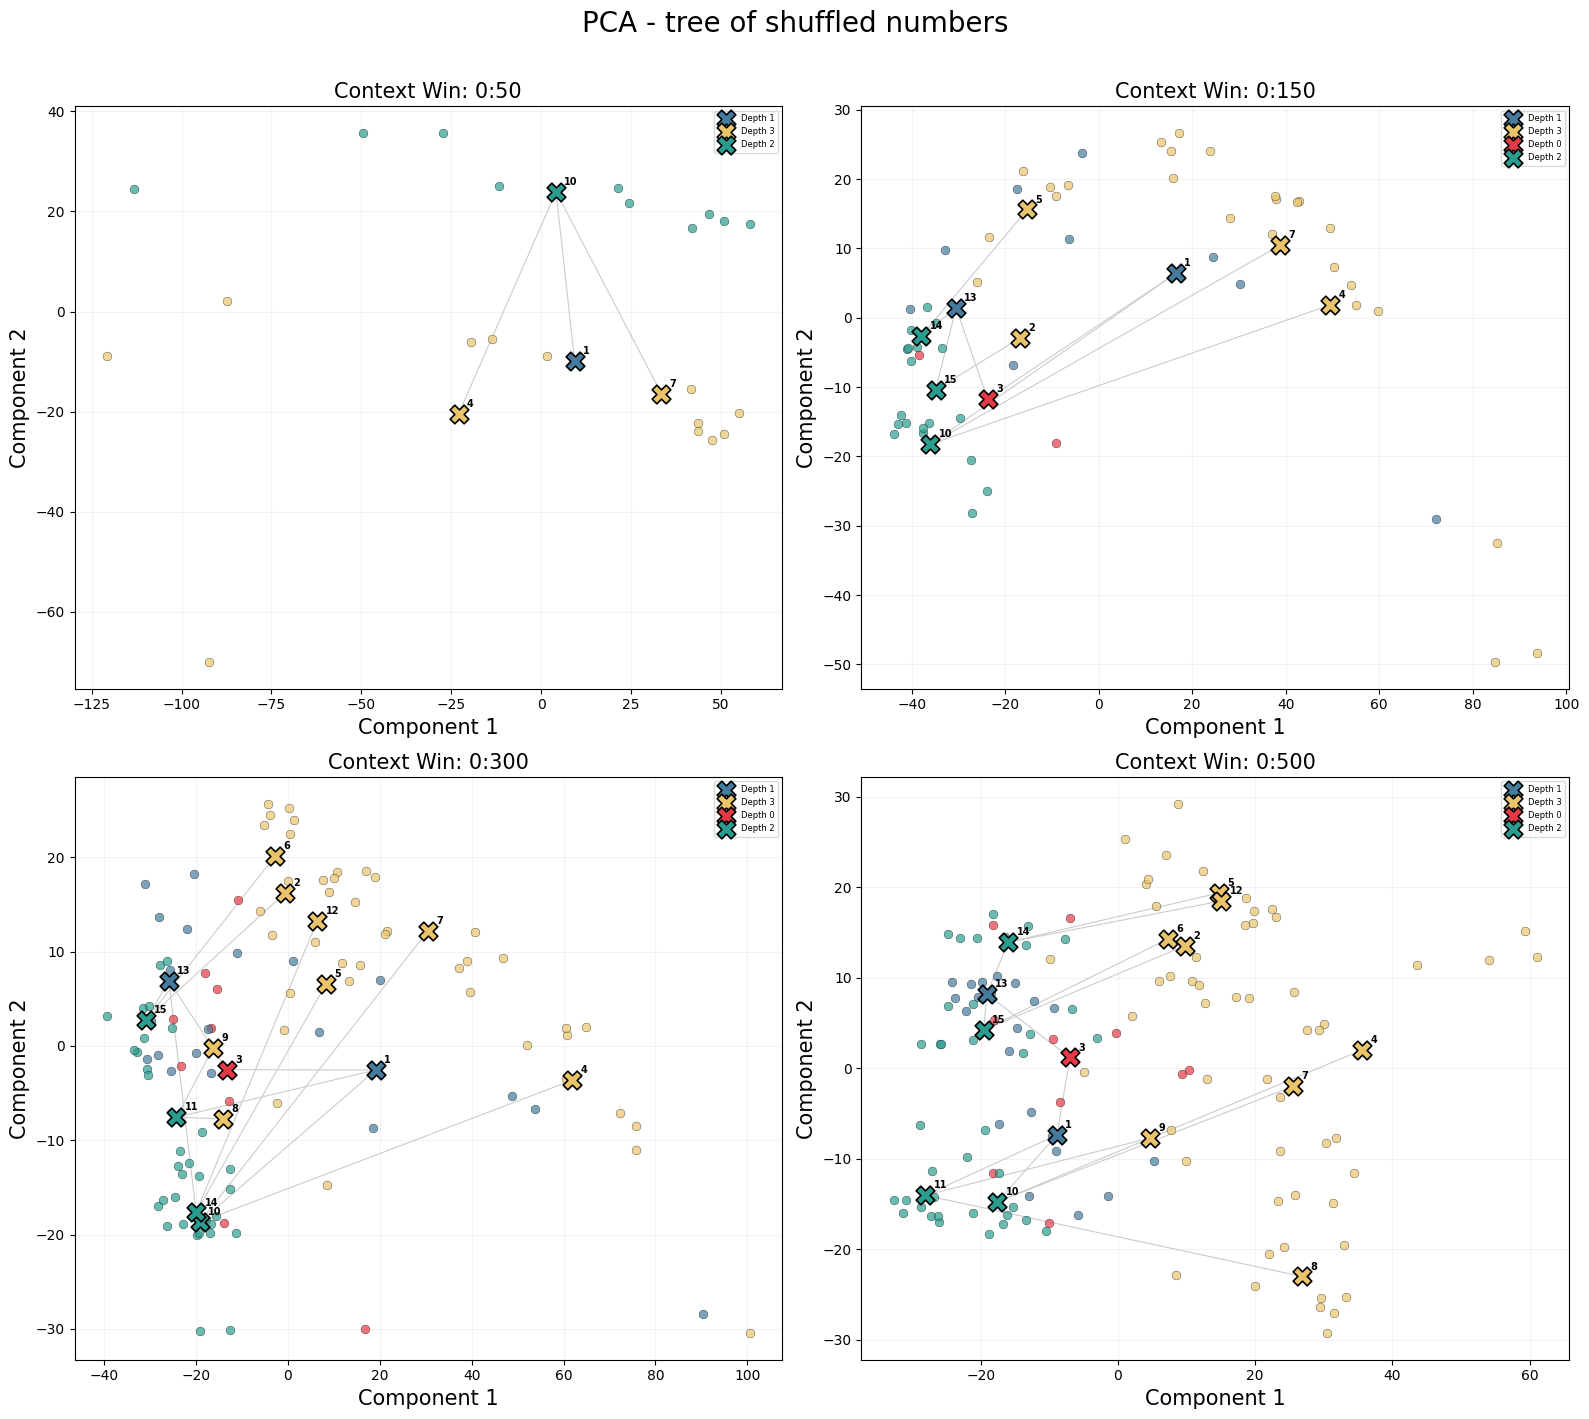

In [8]:
EMB_DIR     = Path("../embeddings/reps&probs32/shuffled_tree_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_tree_numbers/bin_tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,150,300,500]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - tree of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_tree_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

Processing context length: 50
  [] Warning: token '12' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '2' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '8' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 150
Processing context length: 300
Processing context length: 500


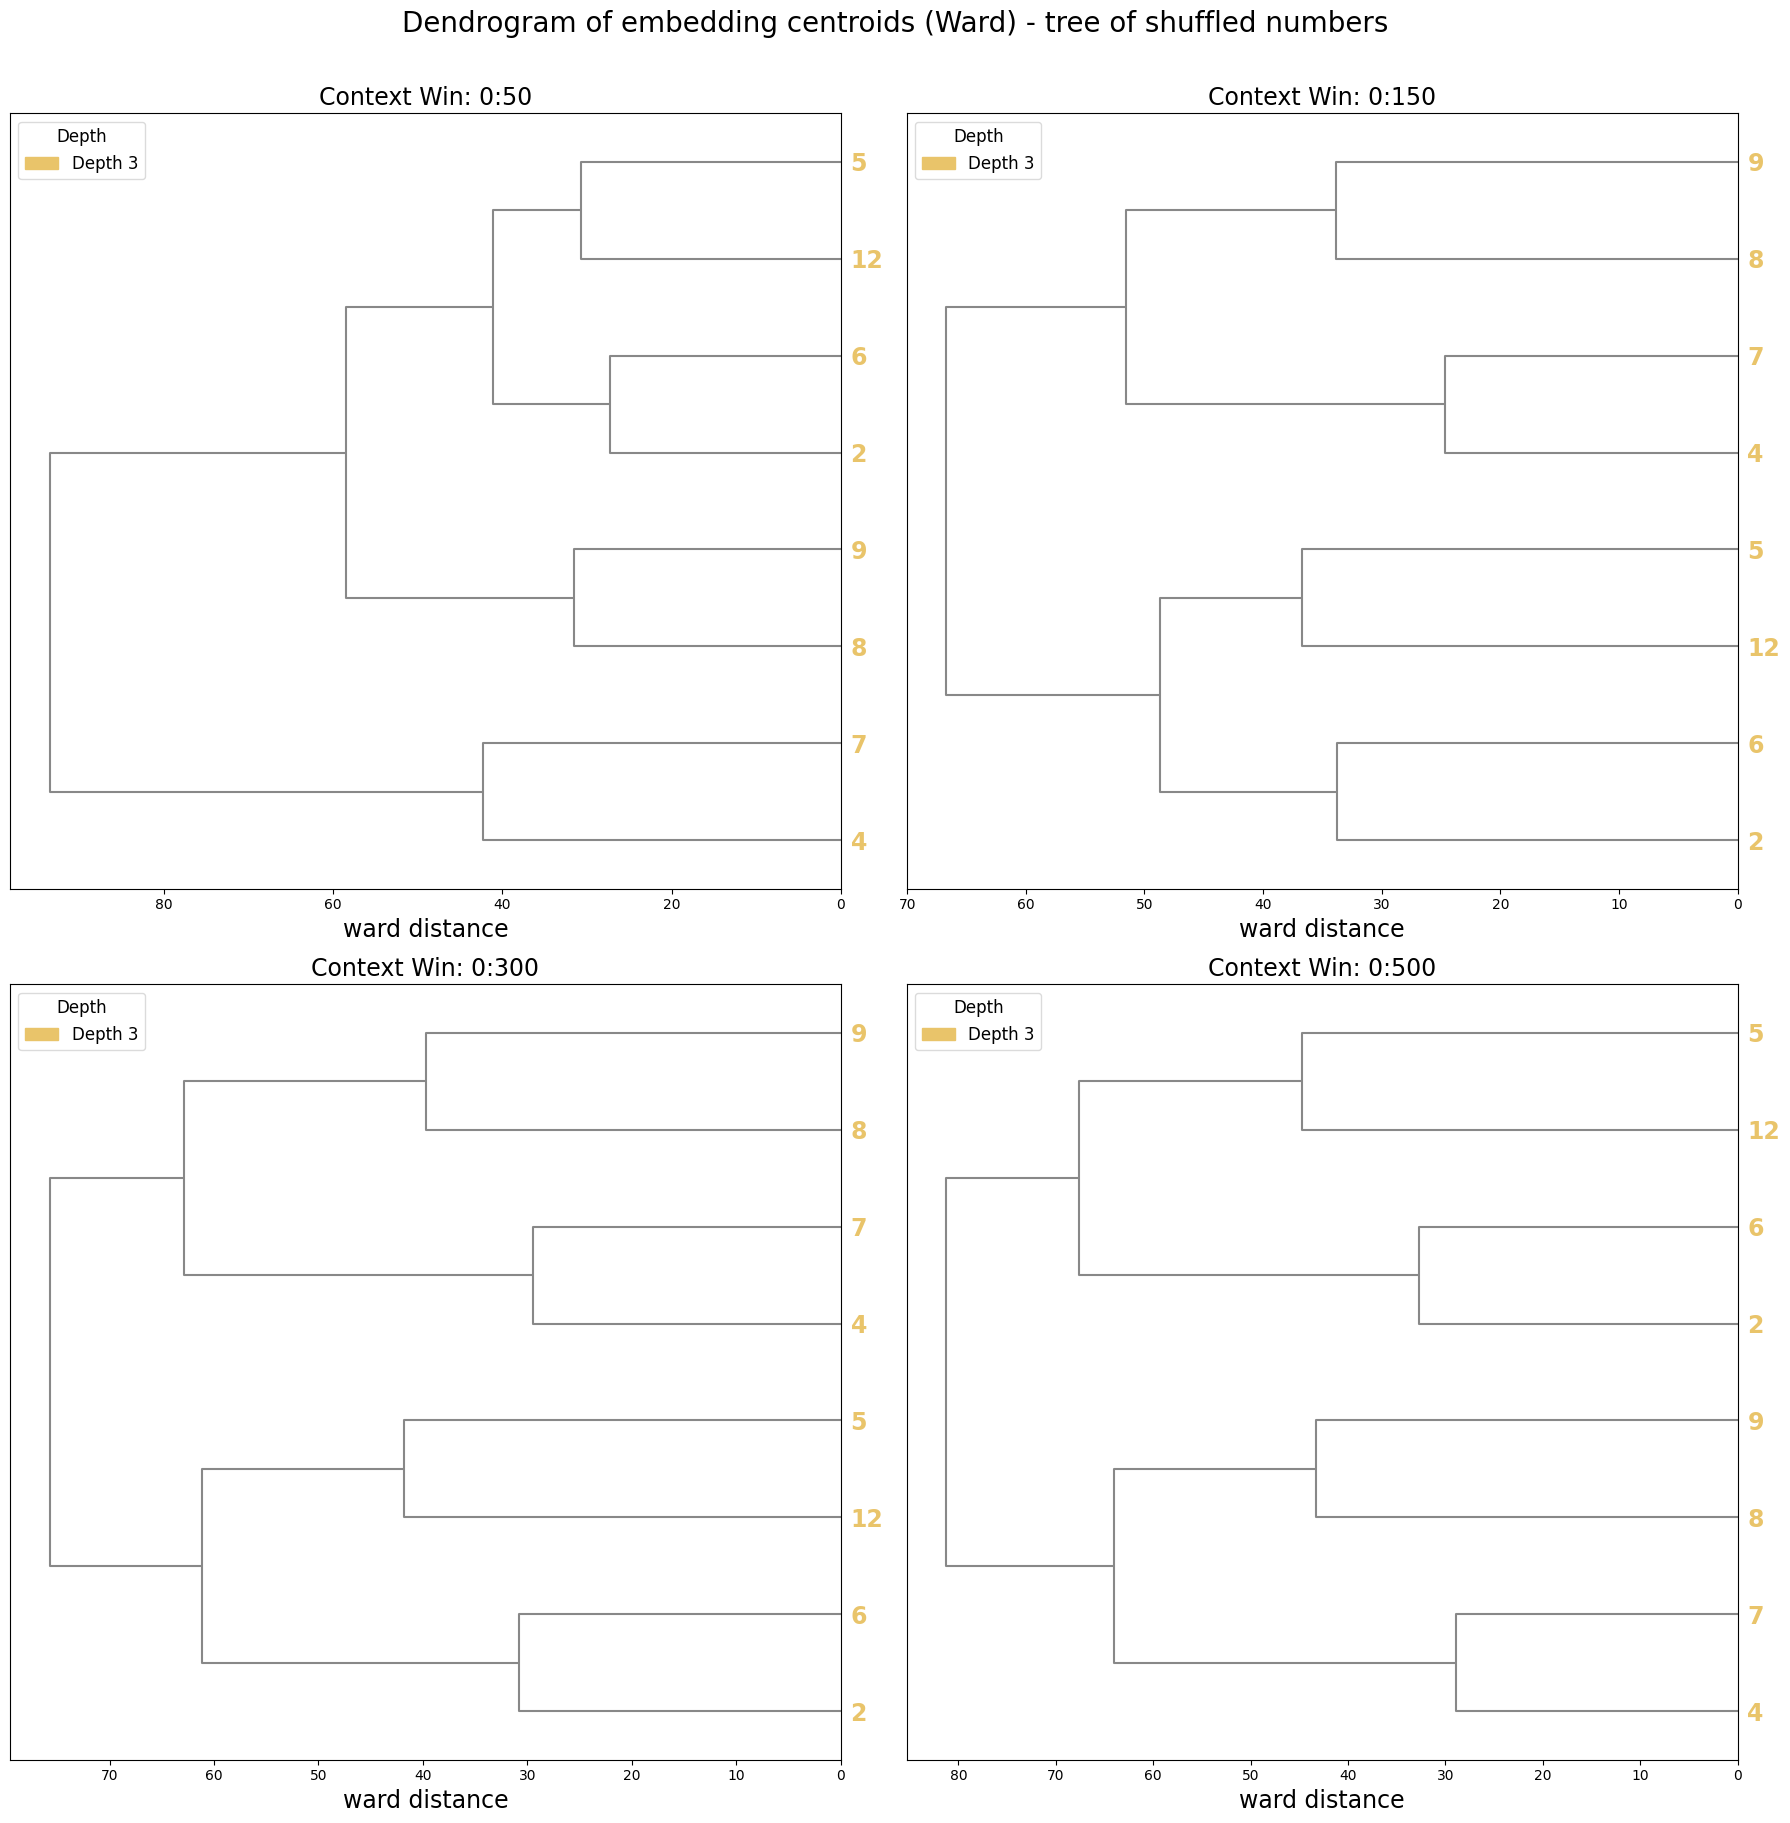

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Dendrogram of embedding centroids (Ward) - tree of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/dendrogram_tree_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

## Exp 2: Numbers Tree (ordered)

  [] Warning: token '15' has only 8 occurrences in [0:100] (requested 10)
  [] Warning: token '12' has only 4 occurrences in [0:100] (requested 10)
  [] Warning: token '8' has only 1 occurrences in [0:100] (requested 10)
  [] Warning: token '11' has only 1 occurrences in [0:300] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:300] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:300] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:300] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:300] (requested 10)
  [] Warning: token '8' has only 9 occurrences in [0:300] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:300] (requested 10)
  [] Warning: token '10' has only 3 occurrences in [0:300] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:500] (requested 10)
  [] Warning: token '5' has only 9 occurrences 

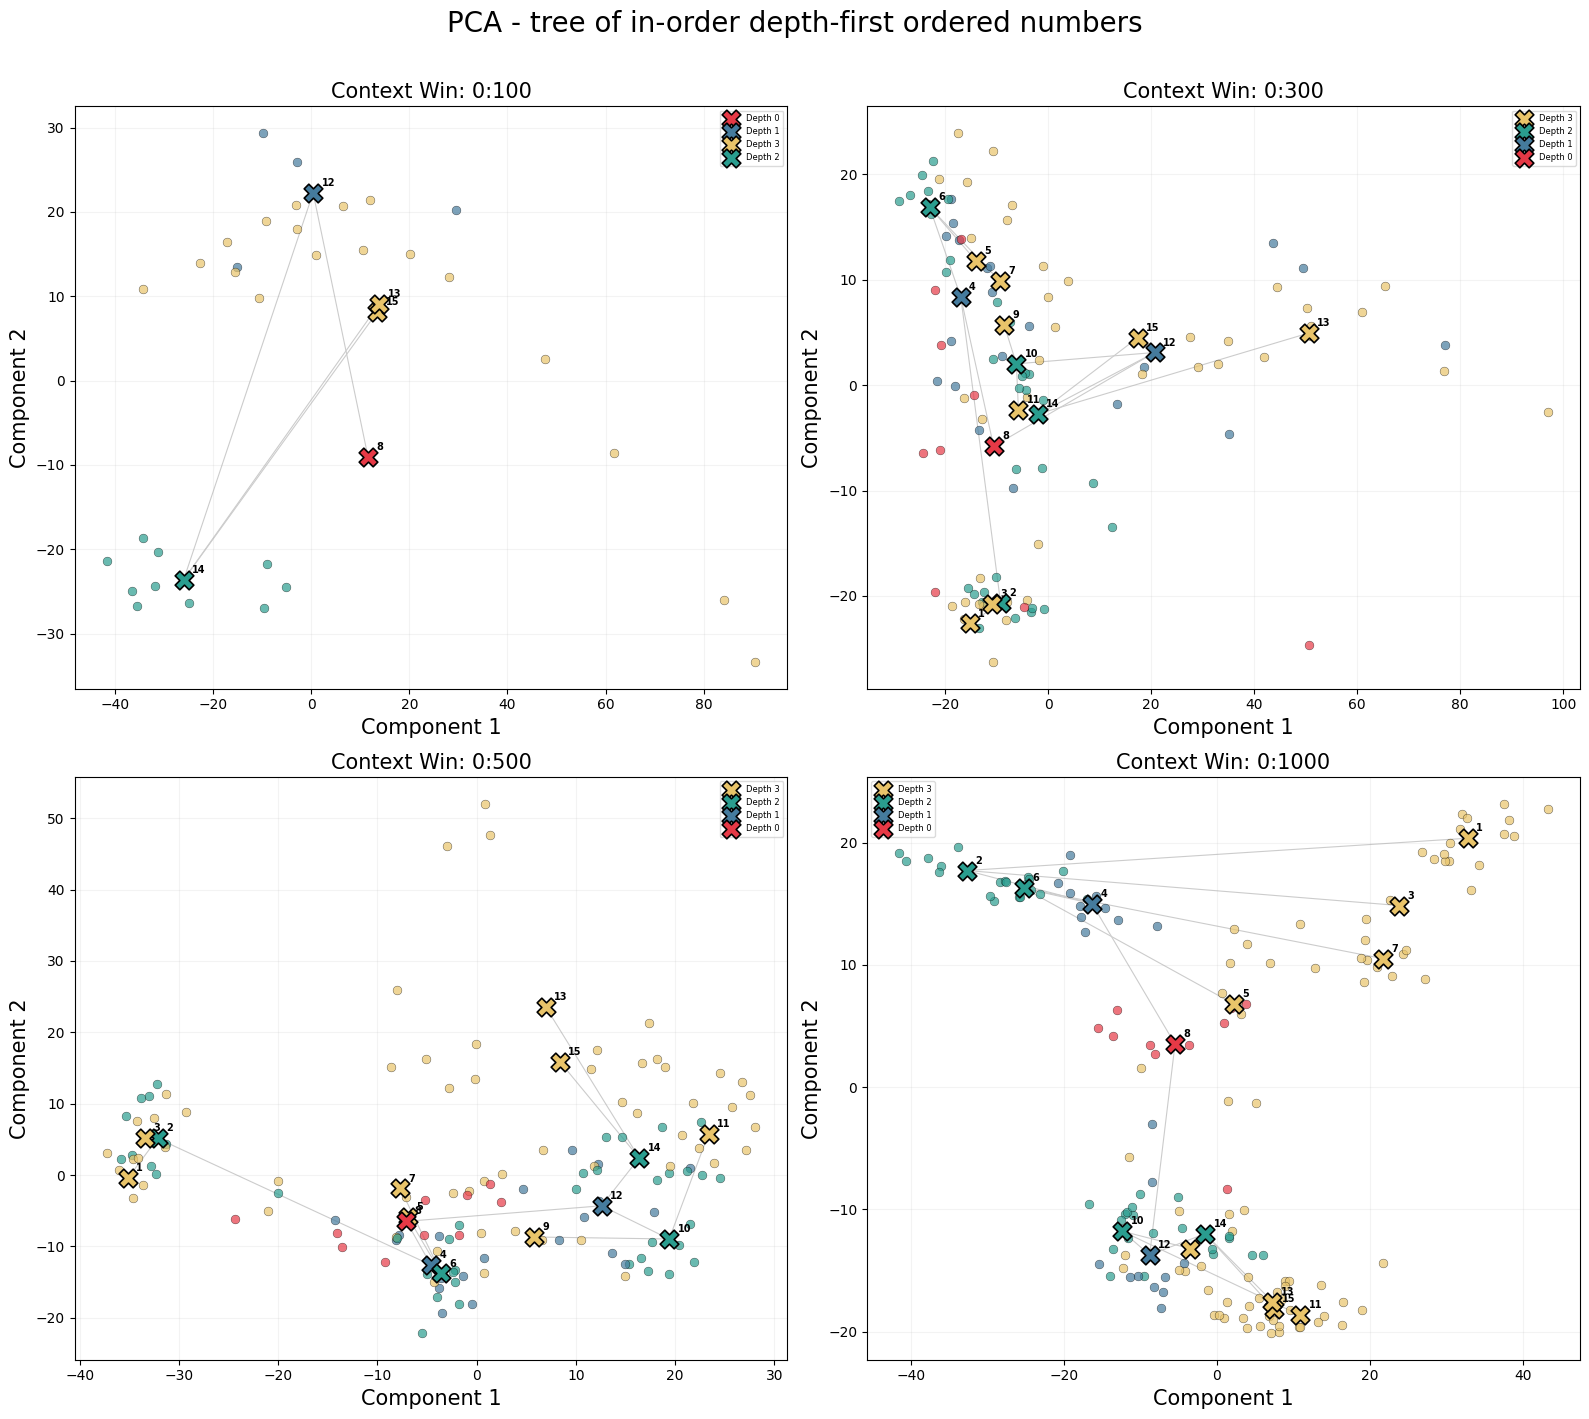

In [76]:
EMB_DIR     = Path("../embeddings/reps&probs32/tree_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_numbers/bin_tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [100,300, 500, 1000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - tree of in-order depth-first ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_tree_inorder_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

Processing context length: 100
  [] Warning: token '1' has only 7 occurrences in [0:100] (requested 10)
  [] Warning: token '3' has only 8 occurrences in [0:100] (requested 10)
  [] Warning: token '7' has only 6 occurrences in [0:100] (requested 10)
Processing context length: 300
Processing context length: 500
Processing context length: 1000


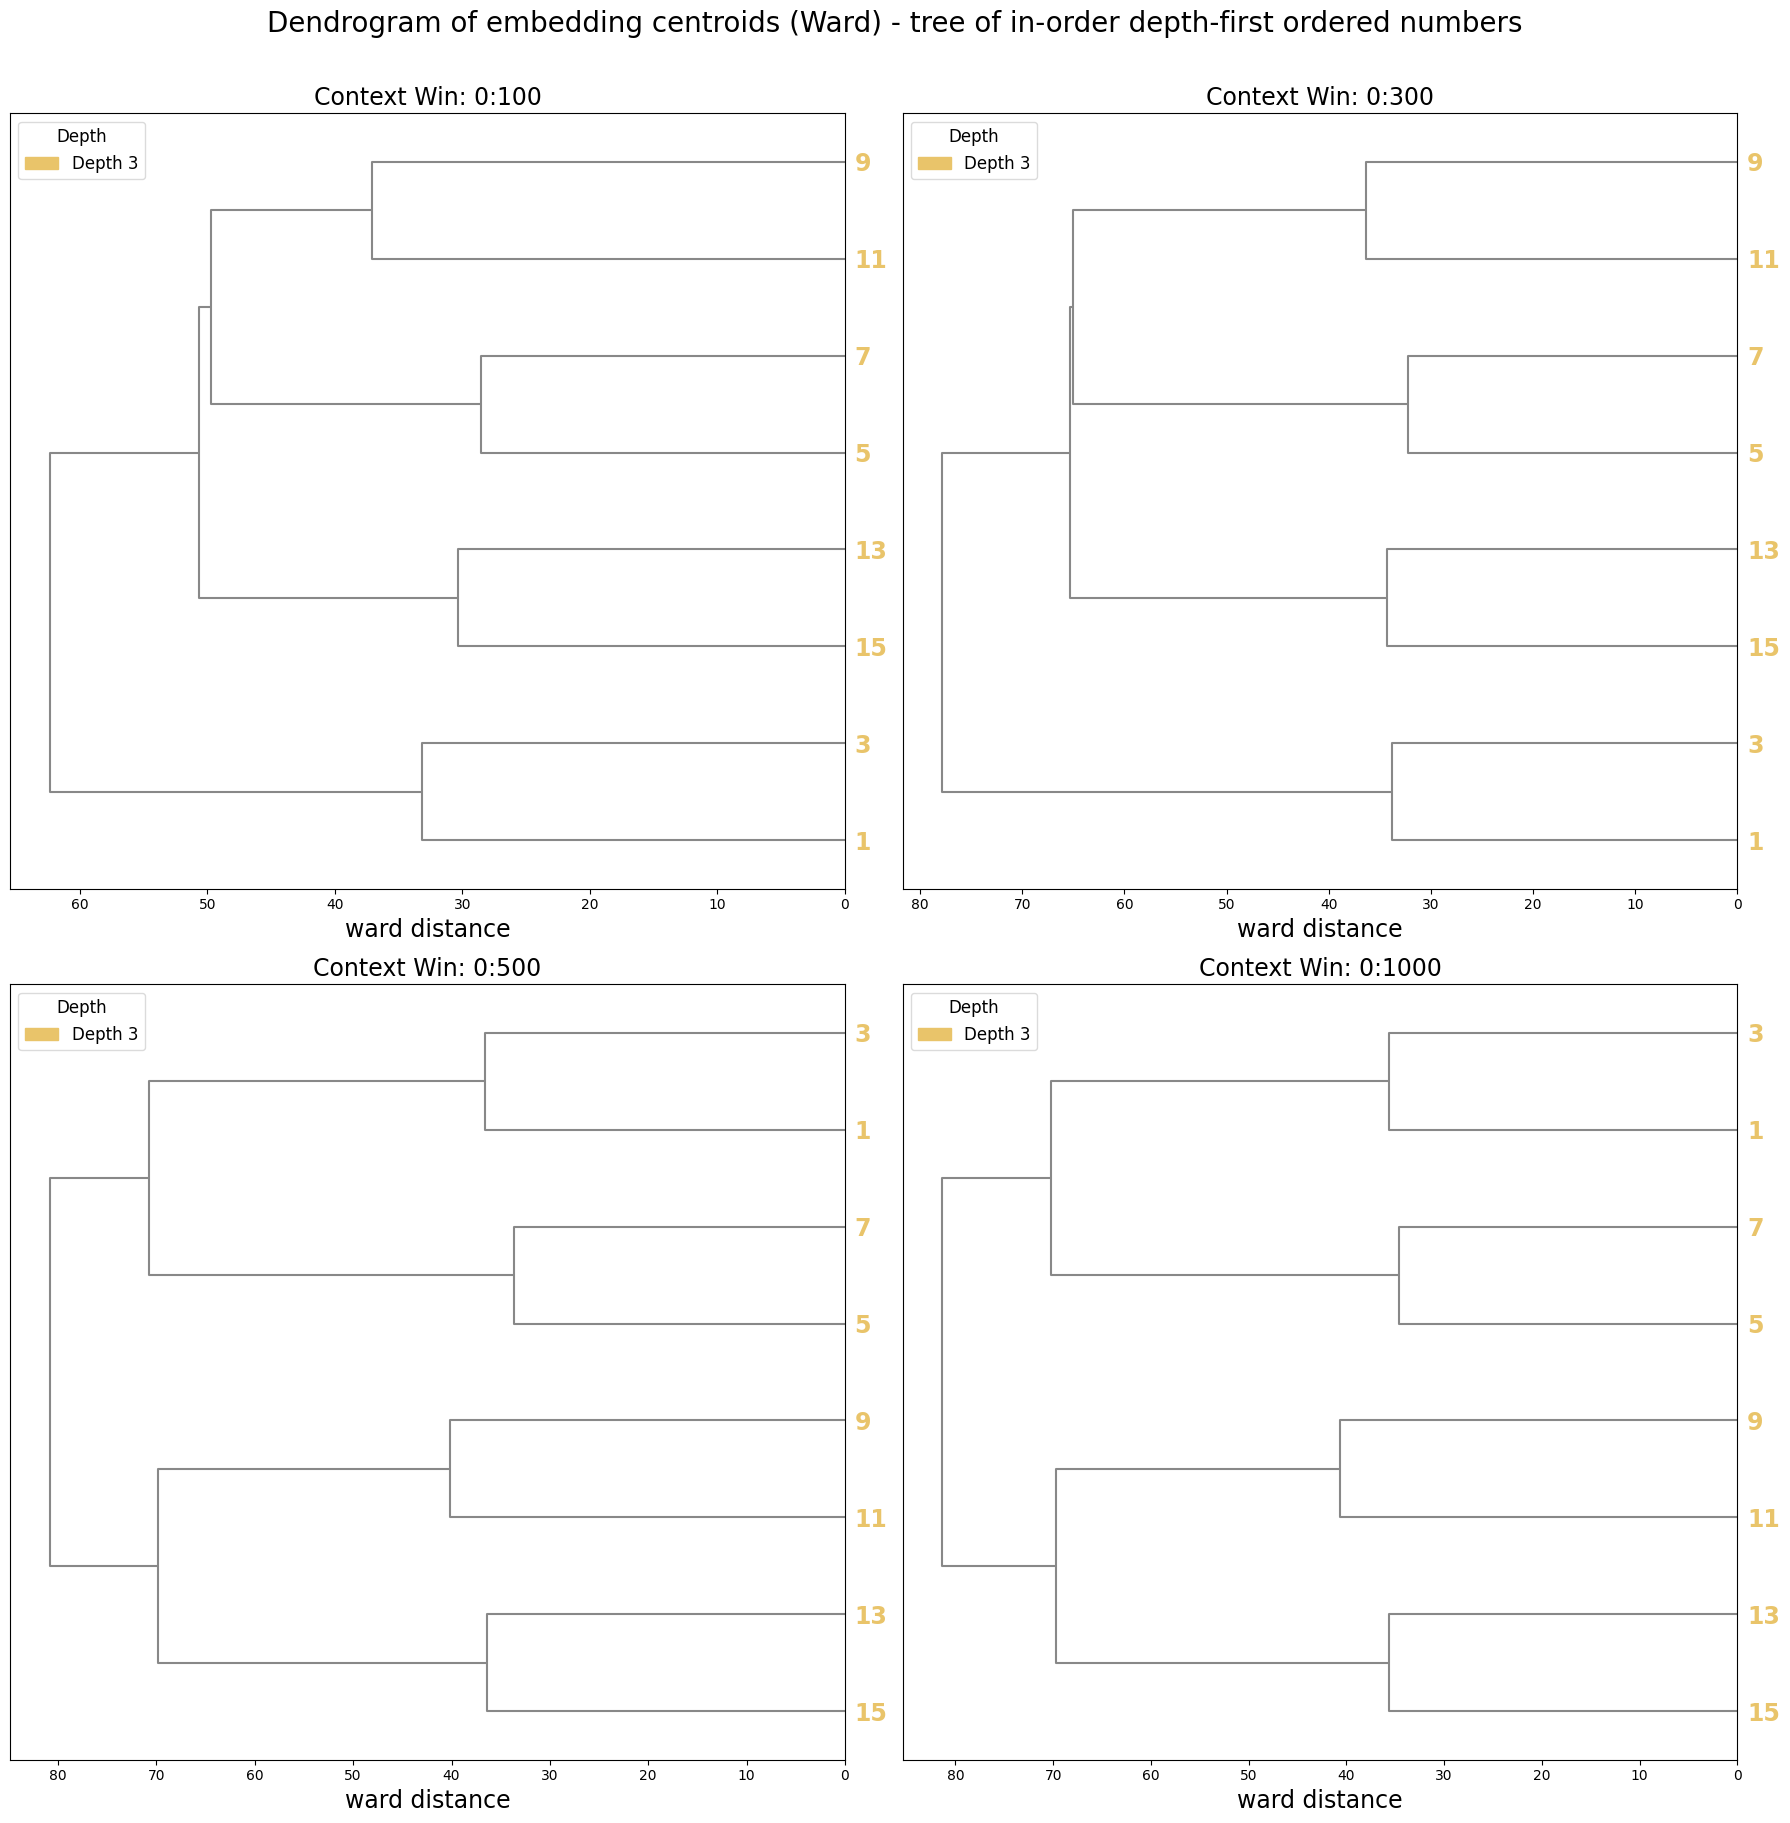

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 3 # quale livello dell'albero dendrogrammo per i centroidi

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Dendrogram of embedding centroids (Ward) - tree of in-order depth-first ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/dendrogram_tree_inorder_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

## Exp 2.1: Numbers Tree - leaves only

  [] Warning: token '15' has only 9 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:150] (requested 10)
  [] Warning: token '5' has only 9 occurrences in [0:150] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:150] (requested 10)


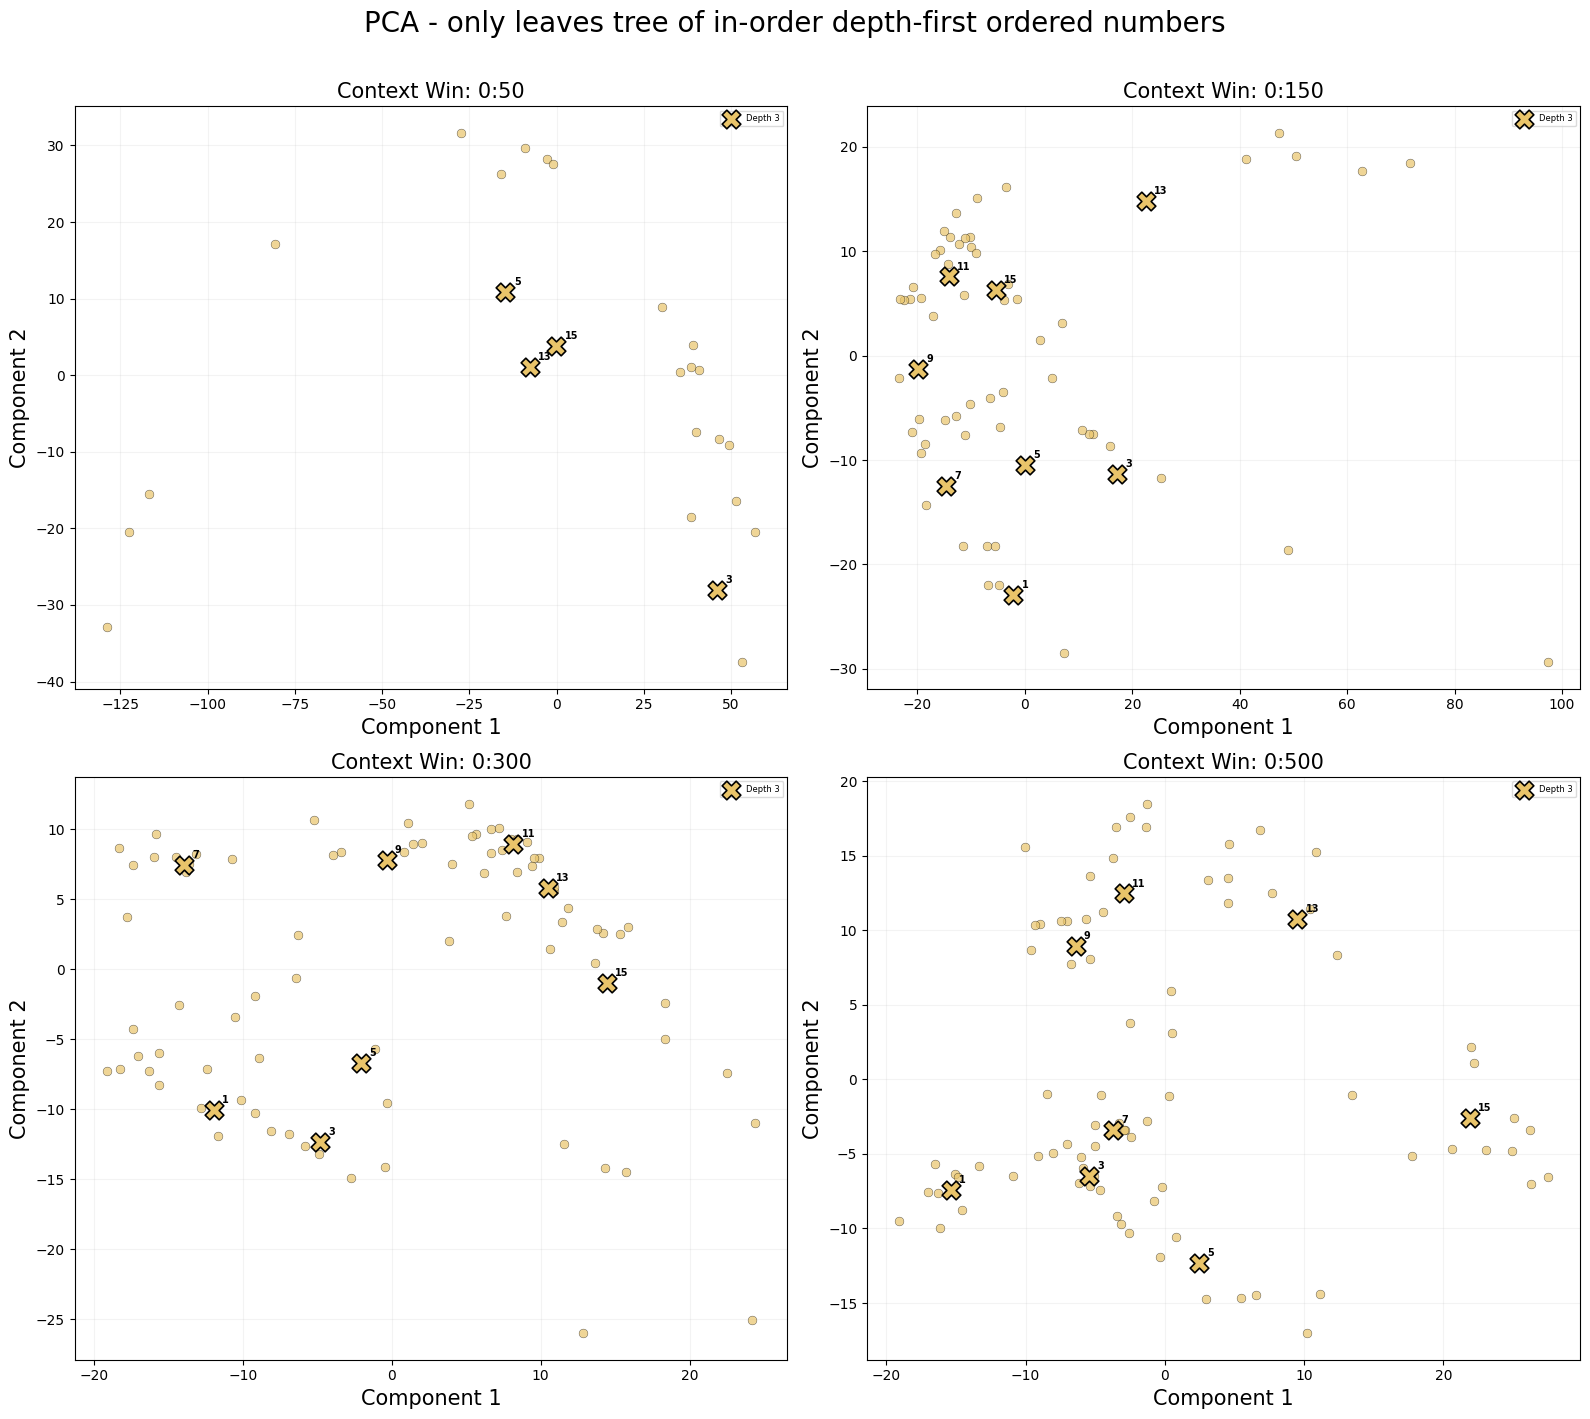

In [18]:
EMB_DIR     = Path("../embeddings/reps&probs32/only_leaves_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,150, 300, 500]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - only leaves tree of in-order depth-first ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_tree_only_leaves_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

Processing context length: 50
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 150
Processing context length: 300
Processing context length: 500


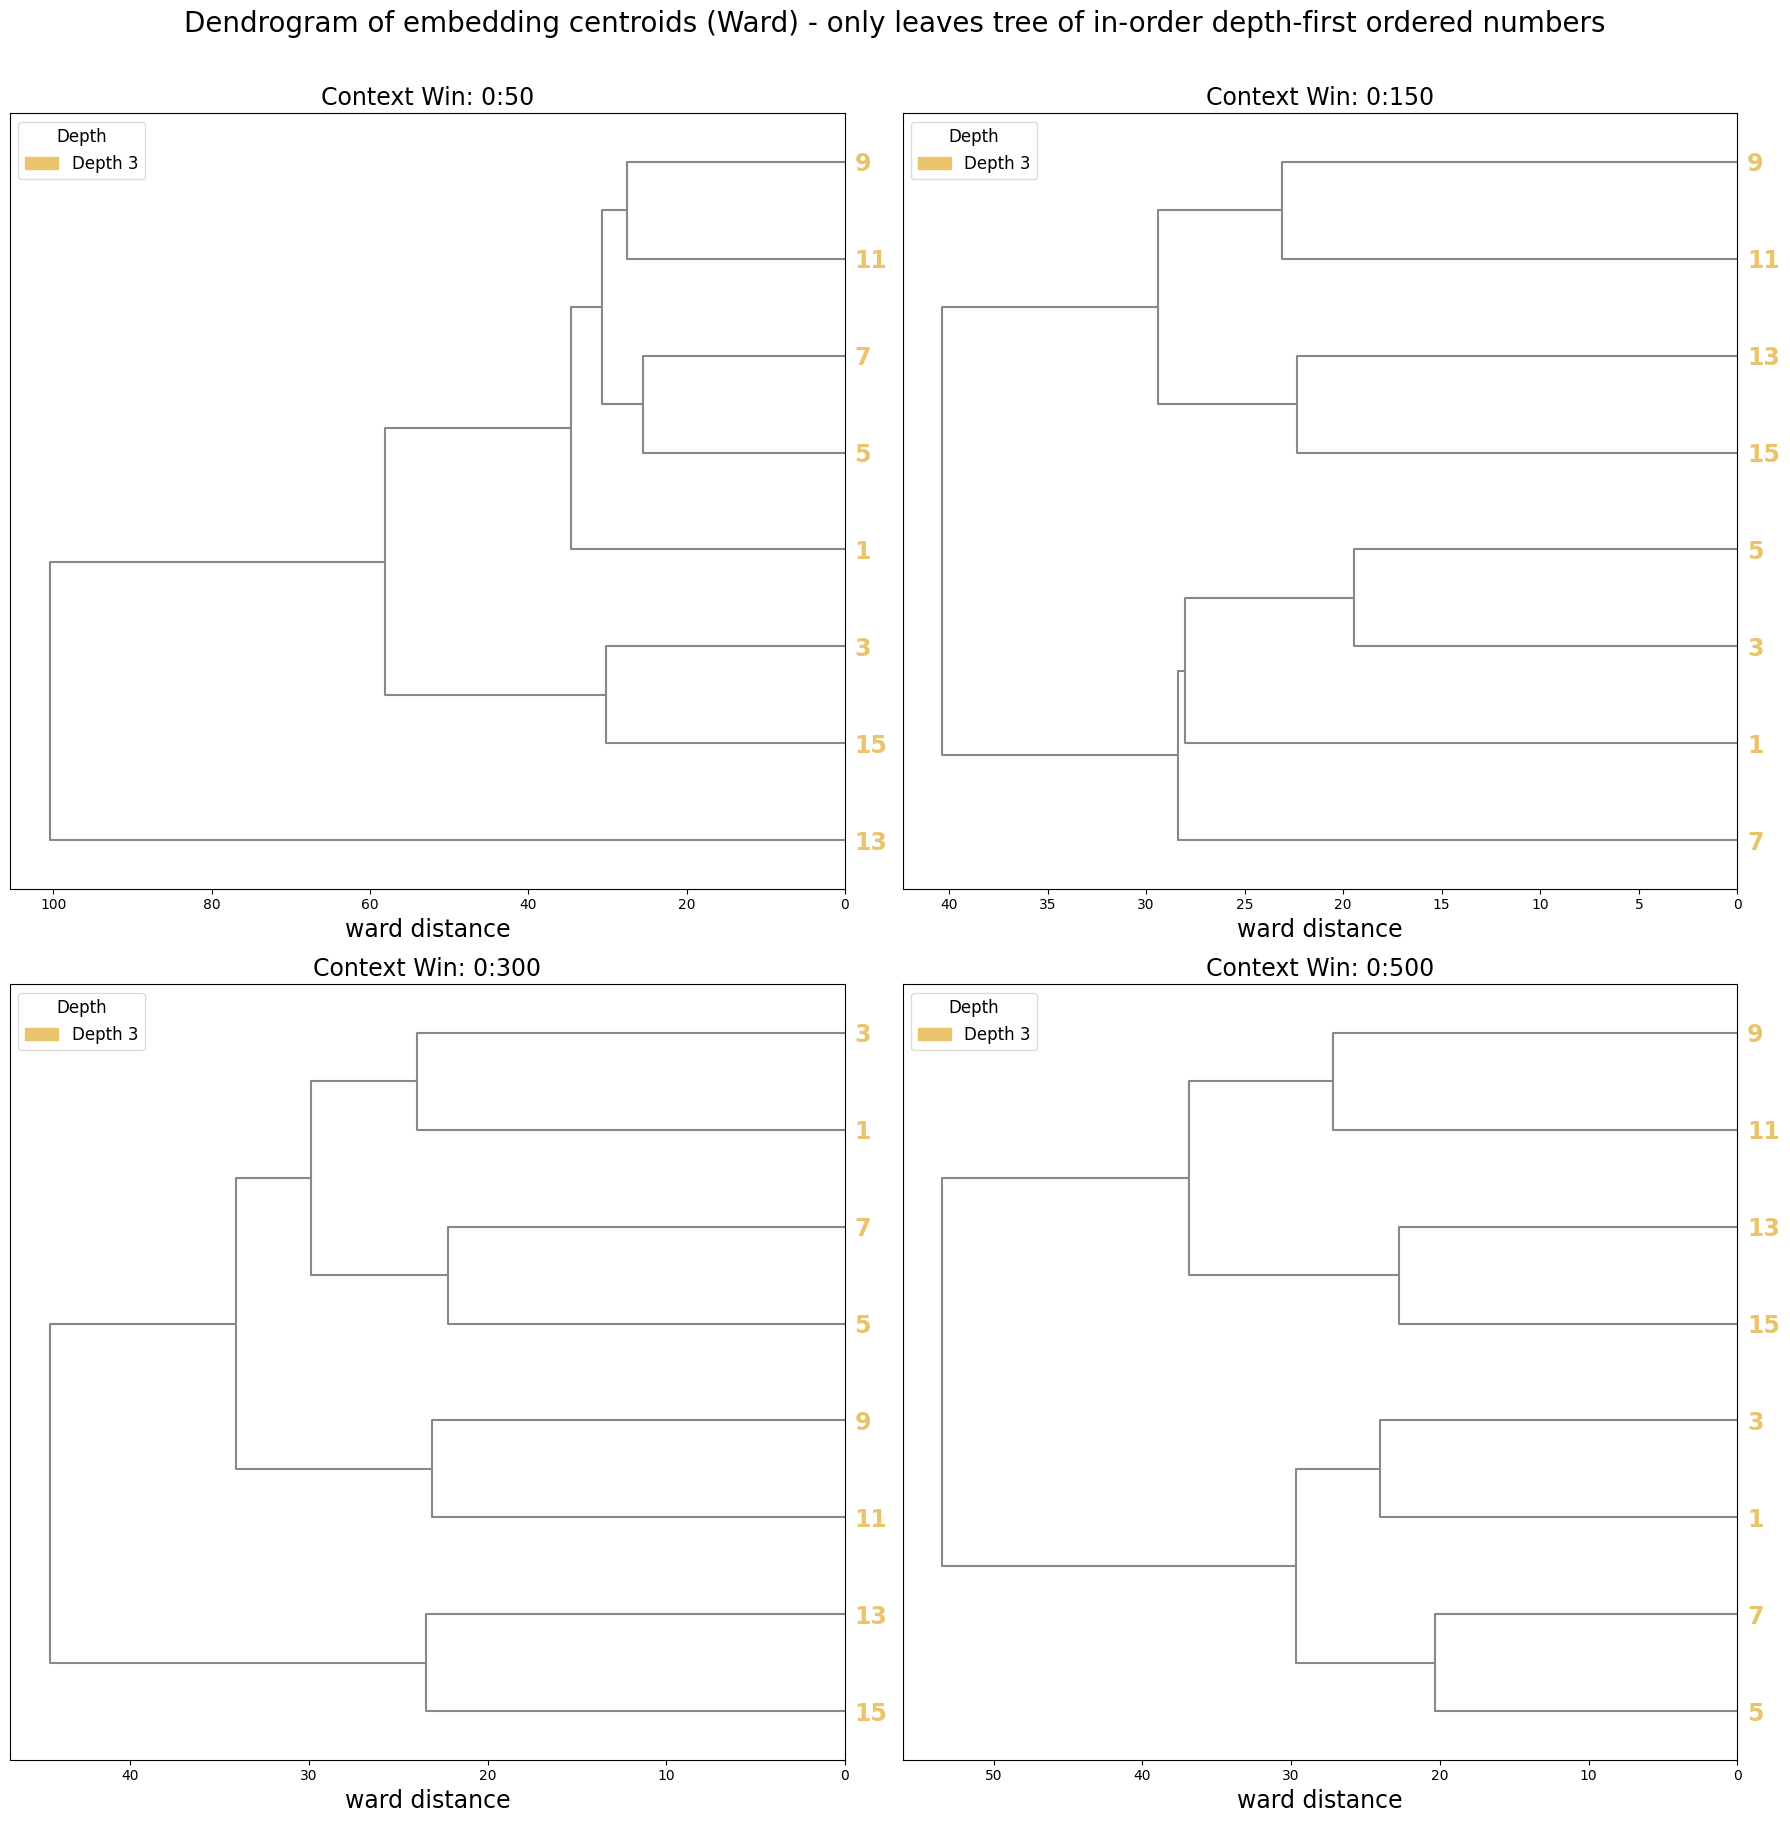

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Dendrogram of embedding centroids (Ward) - only leaves tree of in-order depth-first ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/dendrogram_tree_only_leaves_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

## Exp 2.2: Numbers Tree - leaves only (shuffled)

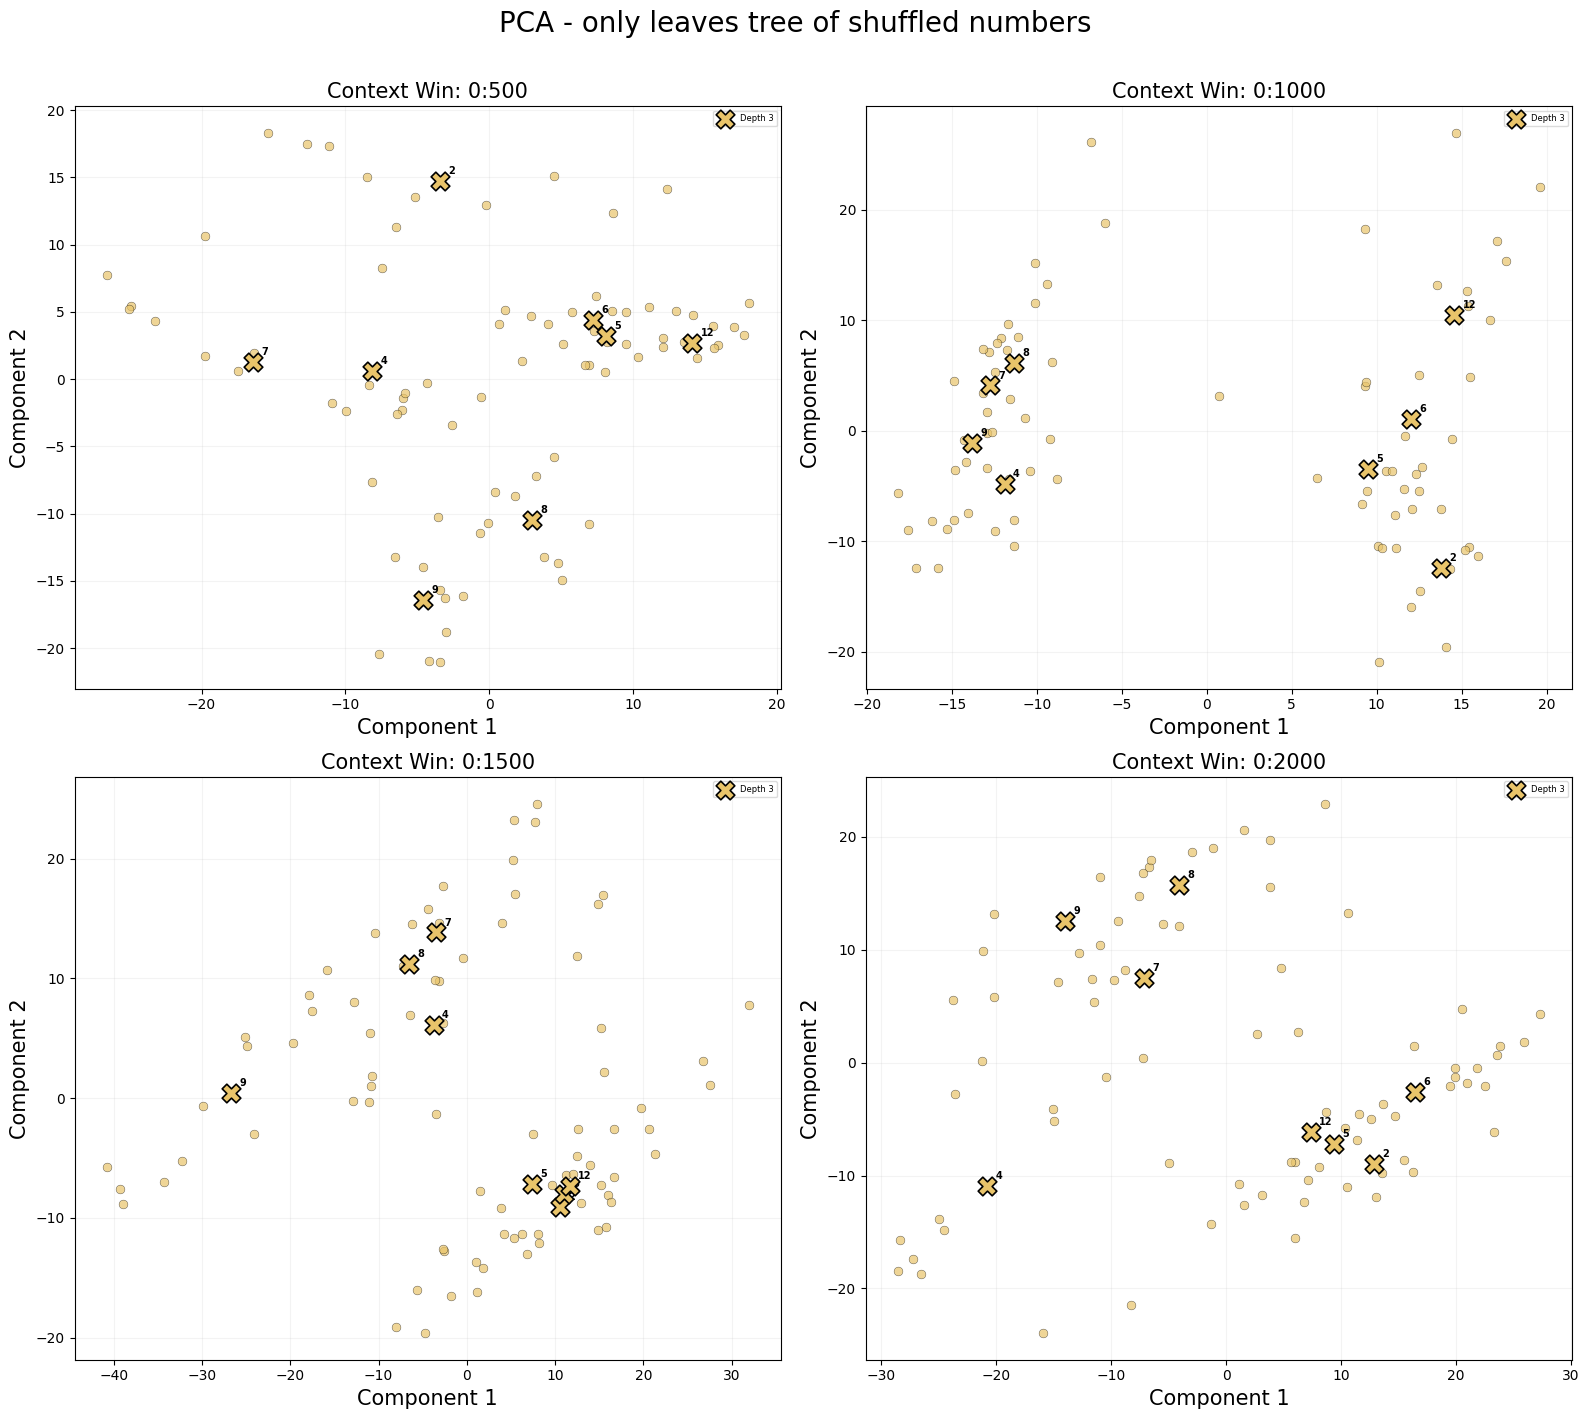

In [28]:
EMB_DIR     = Path("../embeddings/reps&probs32/only_leaves_shuffled_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_shuffled_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500,1000,1500,2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - only leaves tree of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_tree_only_leaves_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

Processing context length: 500
Processing context length: 1000
Processing context length: 1500
Processing context length: 2000


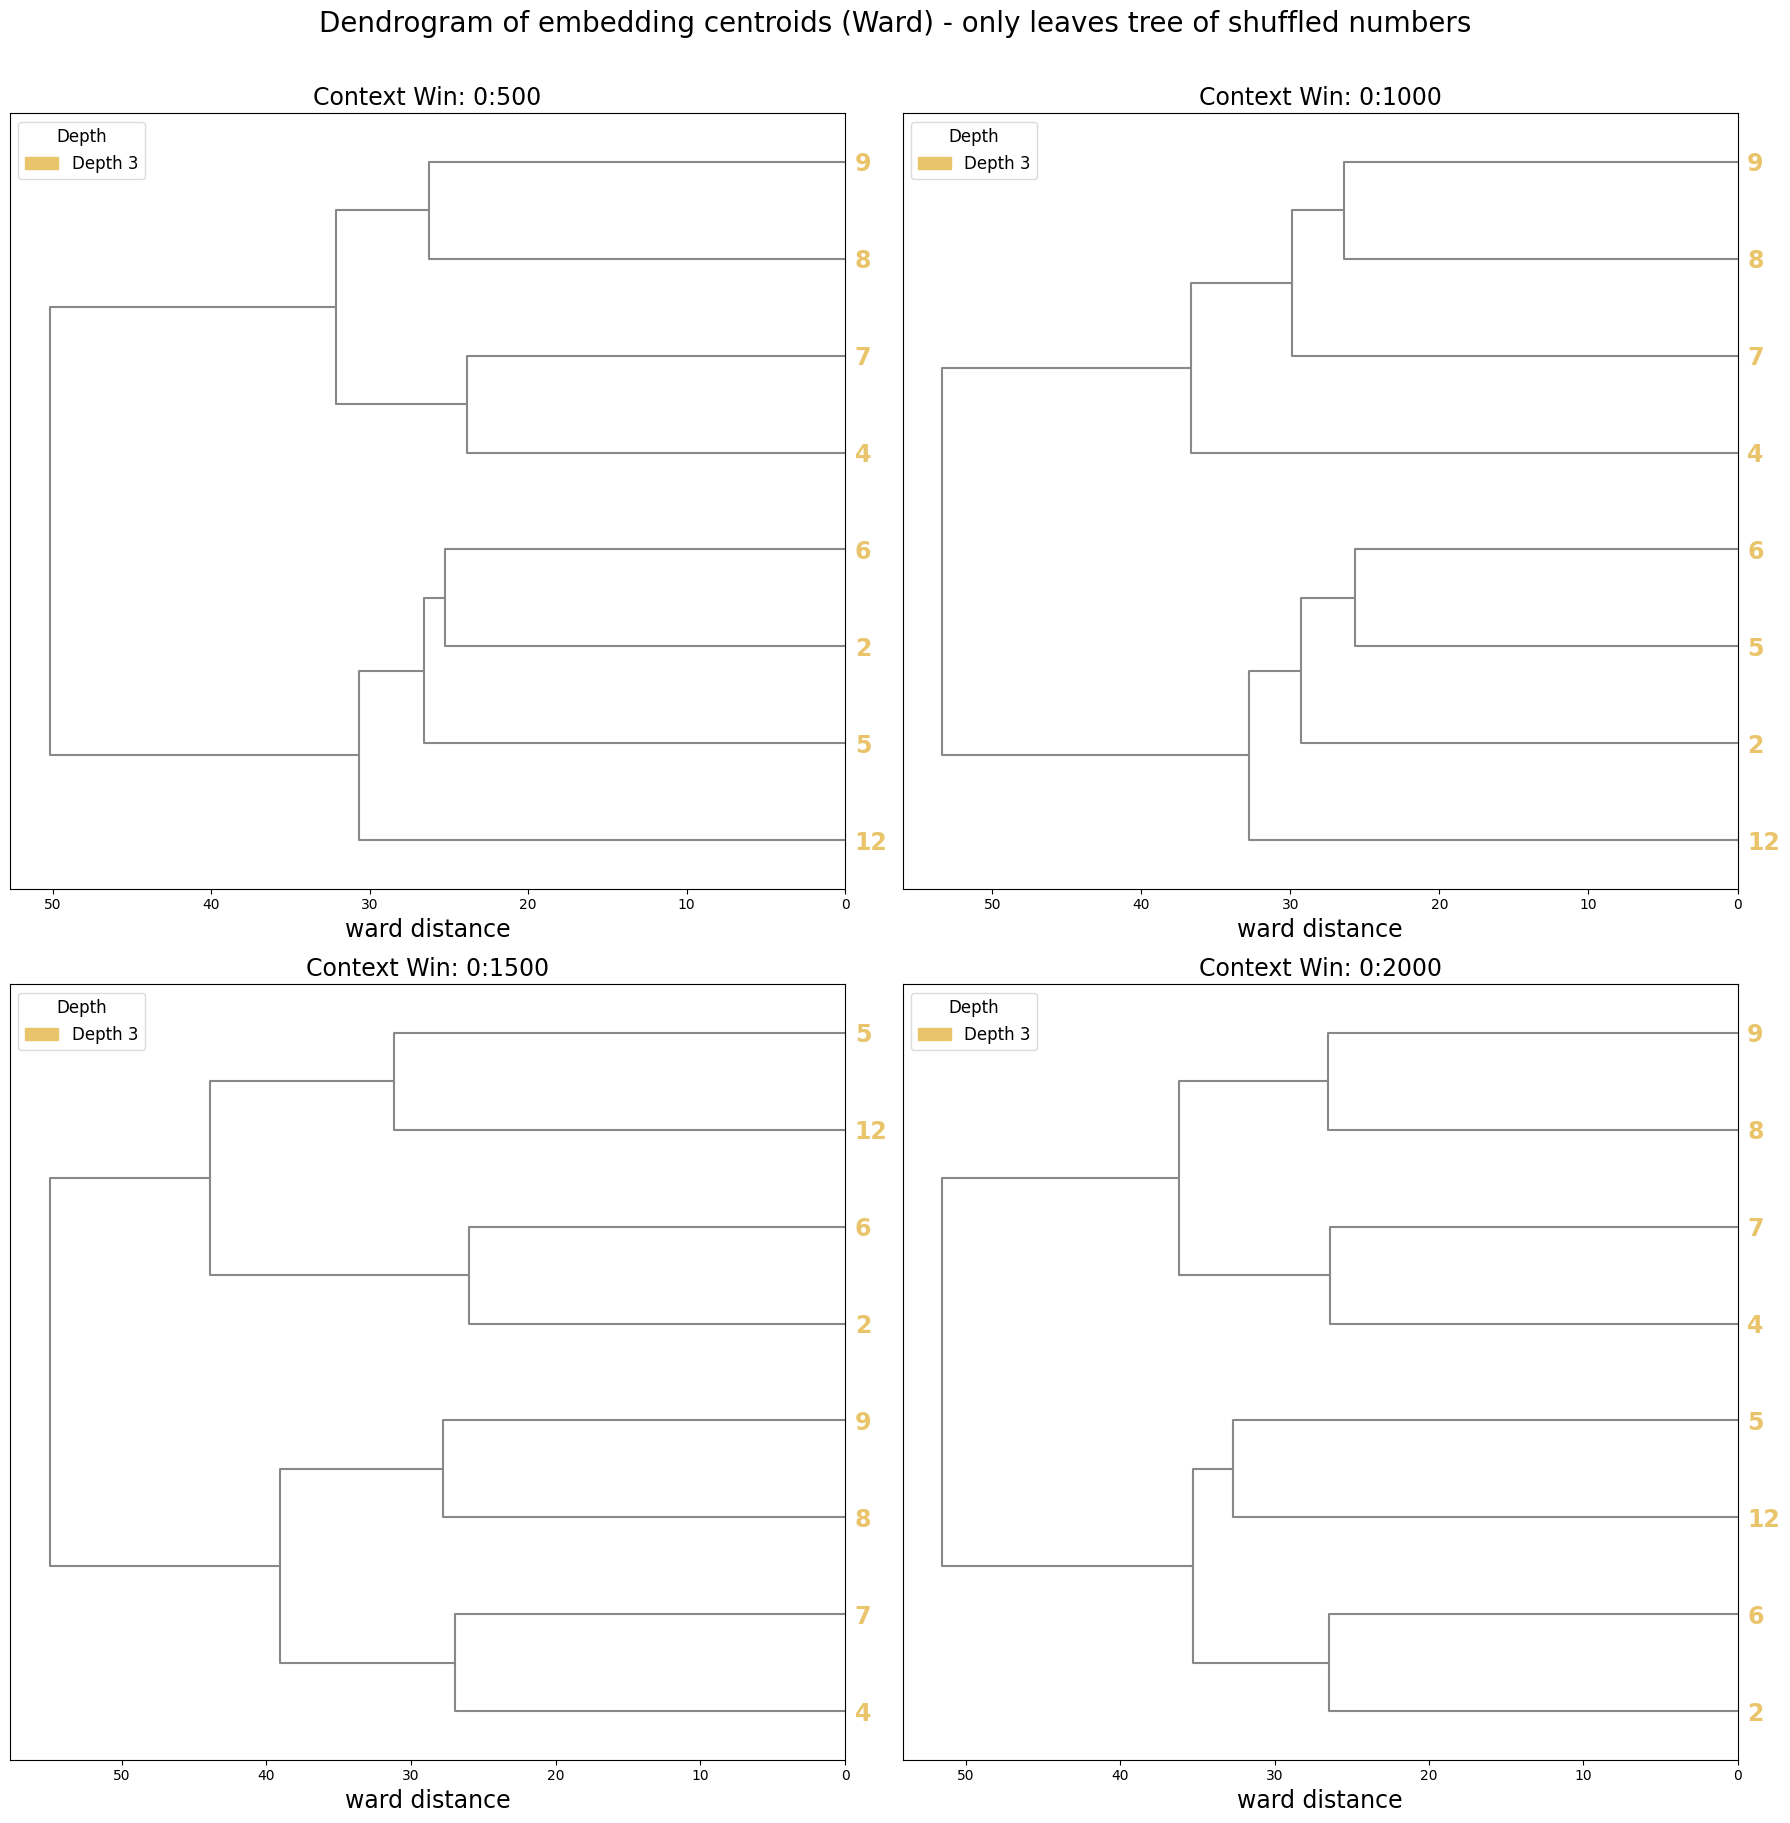

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Dendrogram of embedding centroids (Ward) - only leaves tree of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/dendrogram_tree_only_leaves_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

# QUADRATI E CERCHI

## Exp 4: Numbers Circle (ordered) - IN ORDER TRAVERSAL

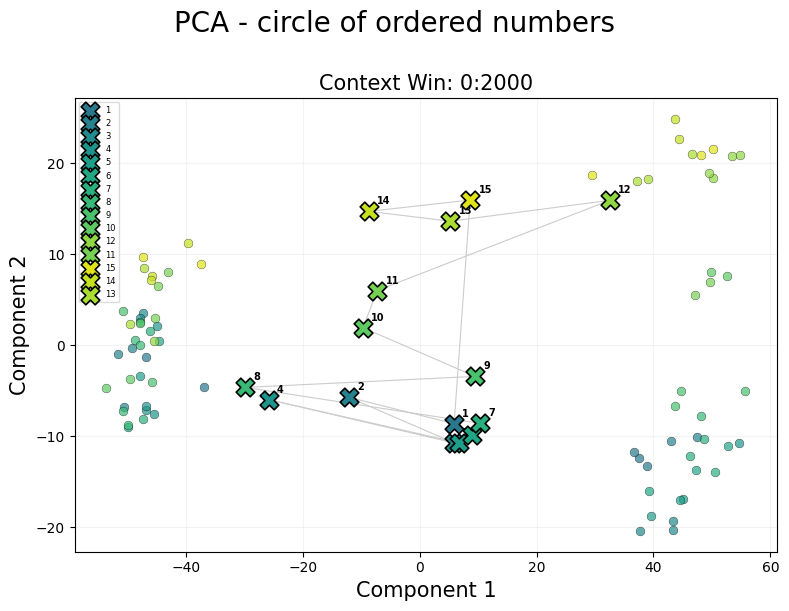

In [30]:
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/circle_numbers/circle_structure.txt")
EMB_DIR     = Path("../embeddings/reps&probs32/circle_numbers")

hp_circle_num = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

ctx = 2000
CTX_LENS = [2000]

# for ax, win_len in zip(axes.flat, CTX_LENS):
pt_path = EMB_DIR / f"reprs_circle_numbers_one_rw_2000_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

fig = plt.figure(figsize=(8, 6))
filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, k=5, t_start=0, t_end=2000)
reducer = PCA(n_components=2, random_state=0)
pca_result = reducer.fit_transform(filtered_embs)
hp_circle_num.plot_reduced_emb(fig.gca(), pca_result, filtered_ids, title=f"Context Win: 0:{2000}", only_centroid=False)

fig.suptitle("PCA - circle of ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_first_components_circle_ordered_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

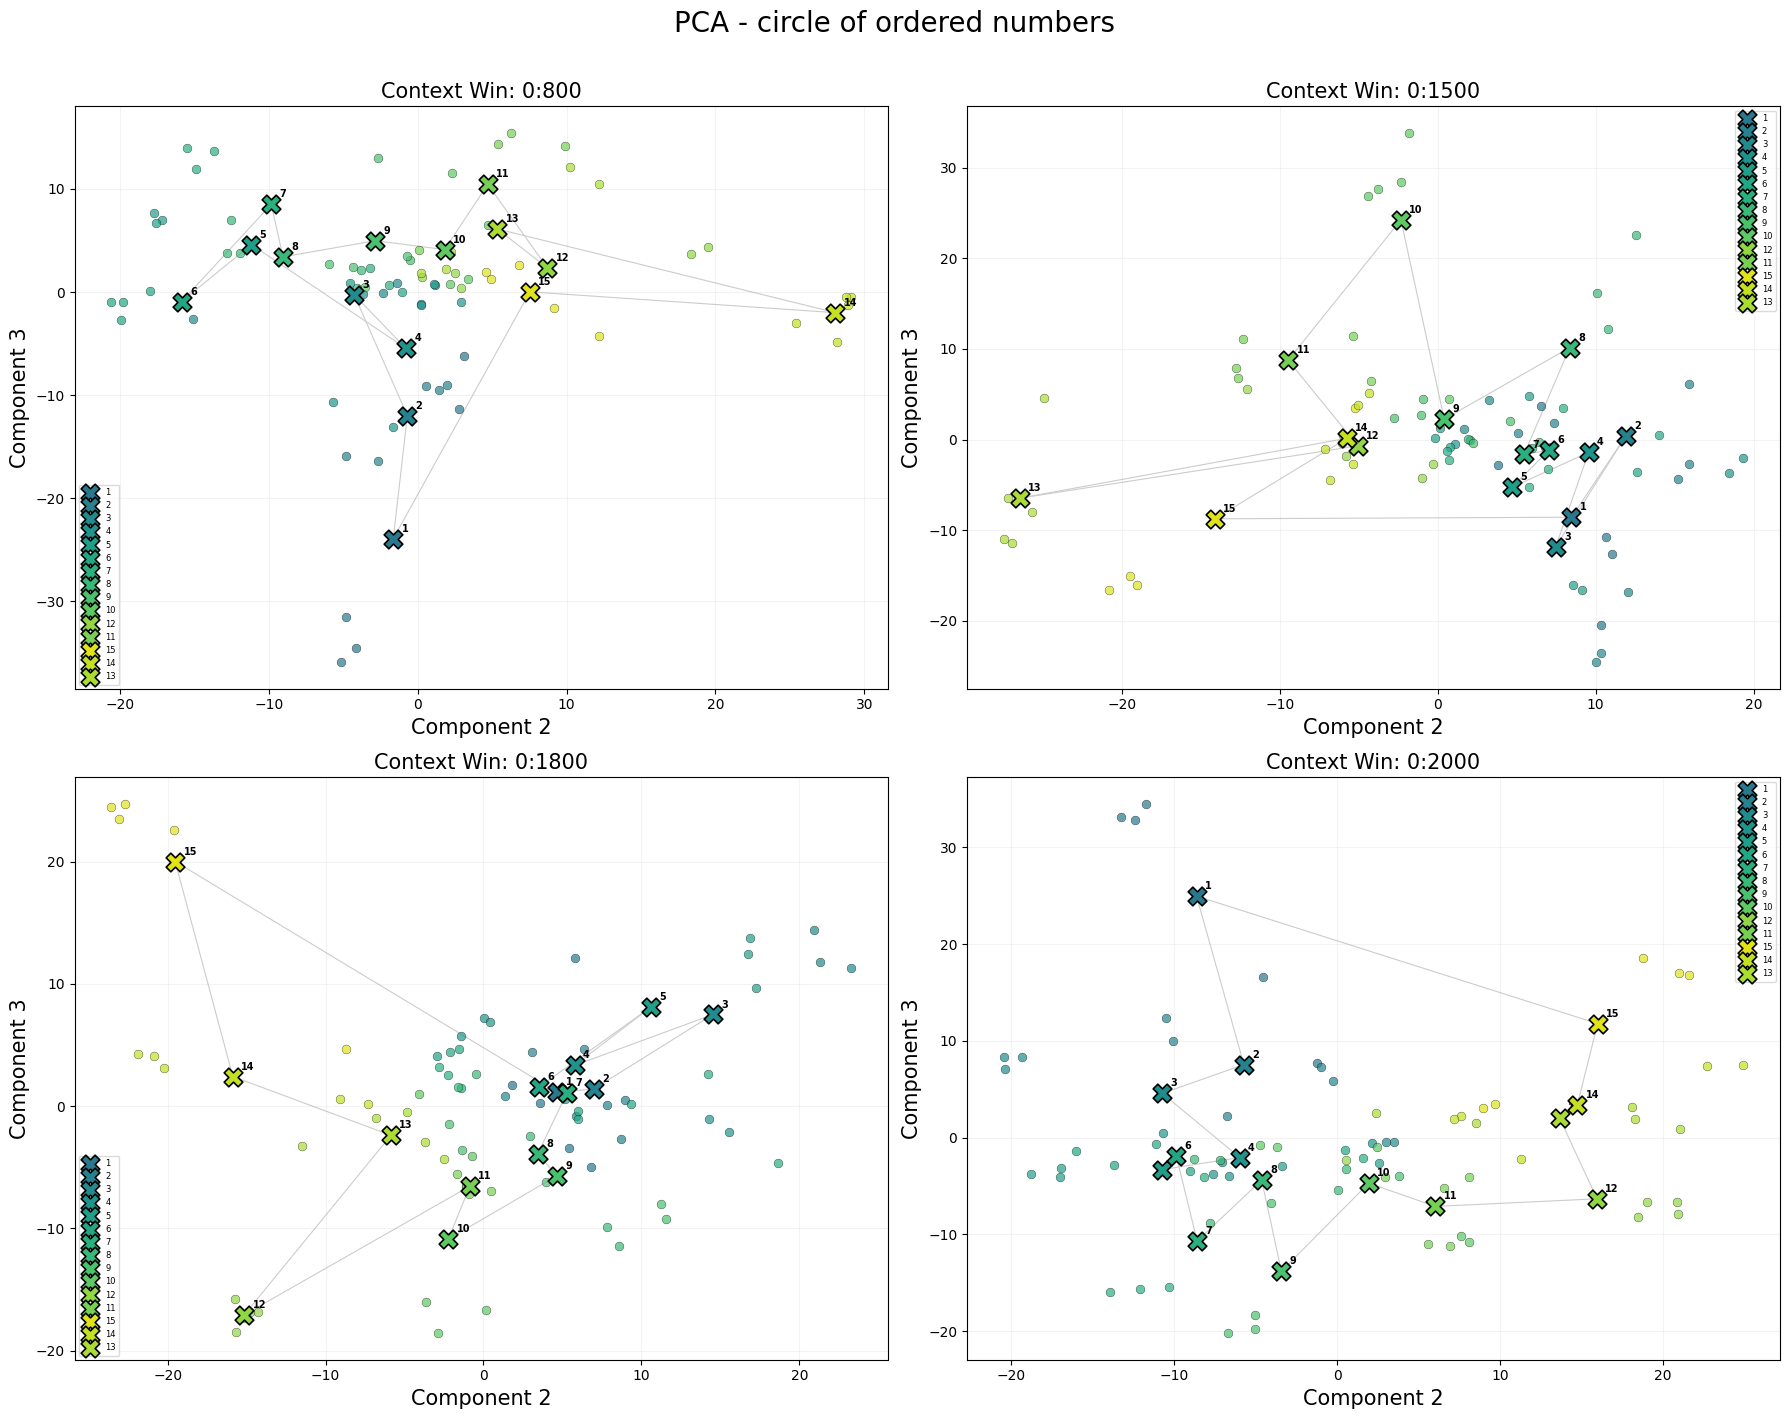

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [800, 1500,1800, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=5, t_start=0, t_end=win_len)
    reducer = PCA(n_components=3, random_state=0)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=True)

fig.suptitle("PCA - circle of ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_second_components_circle_ordered_numbers.png", dpi=300, bbox_inches='tight')
plt.show()    

## Exp 5: Numbers Grid (ordered) - IN ORDER TRAVERSAL

  [] Warning: token '15' has only 4 occurrences in [0:250] (requested 10)
  [] Warning: token '11' has only 3 occurrences in [0:250] (requested 10)
  [] Warning: token '13' has only 7 occurrences in [0:250] (requested 10)
  [] Warning: token '14' has only 6 occurrences in [0:250] (requested 10)
  [] Warning: token '1' has only 7 occurrences in [0:250] (requested 10)
  [] Warning: token '5' has only 2 occurrences in [0:250] (requested 10)
  [] Warning: token '6' has only 9 occurrences in [0:250] (requested 10)
  [] Warning: token '9' has only 6 occurrences in [0:250] (requested 10)
  [] Warning: token '10' has only 2 occurrences in [0:250] (requested 10)


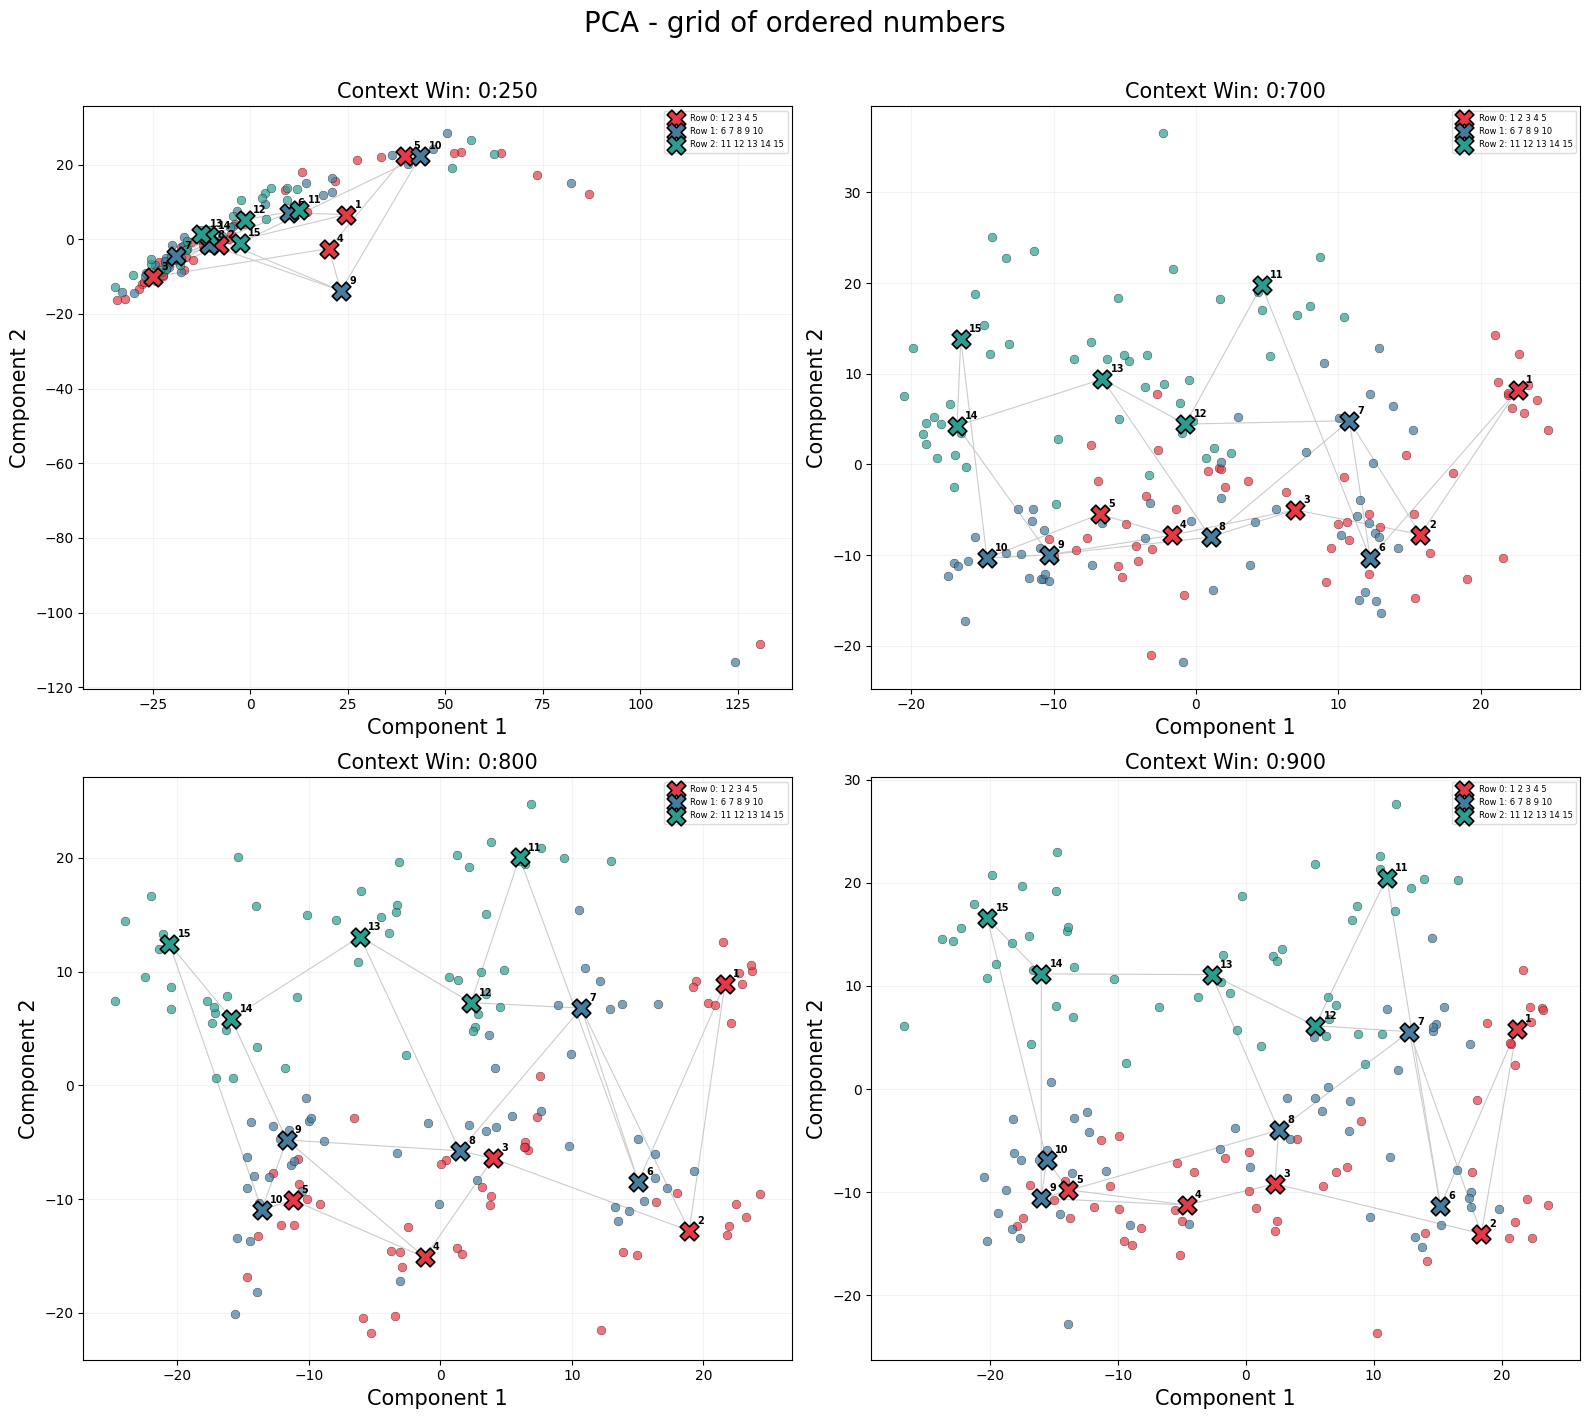

In [42]:
EMB_DIR     = Path("../embeddings/reps&probs32/grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [250,700,800,900]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_numbers_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - grid of ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_grid_ordered_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

# GIORNI

## Days Tree (3 levels)

  [] Warning: token 'Wednesday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 6 occurrences in [0:150] (requested 10)
  [] Warning: token 'Friday' has only 7 occurrences in [0:150] (requested 10)


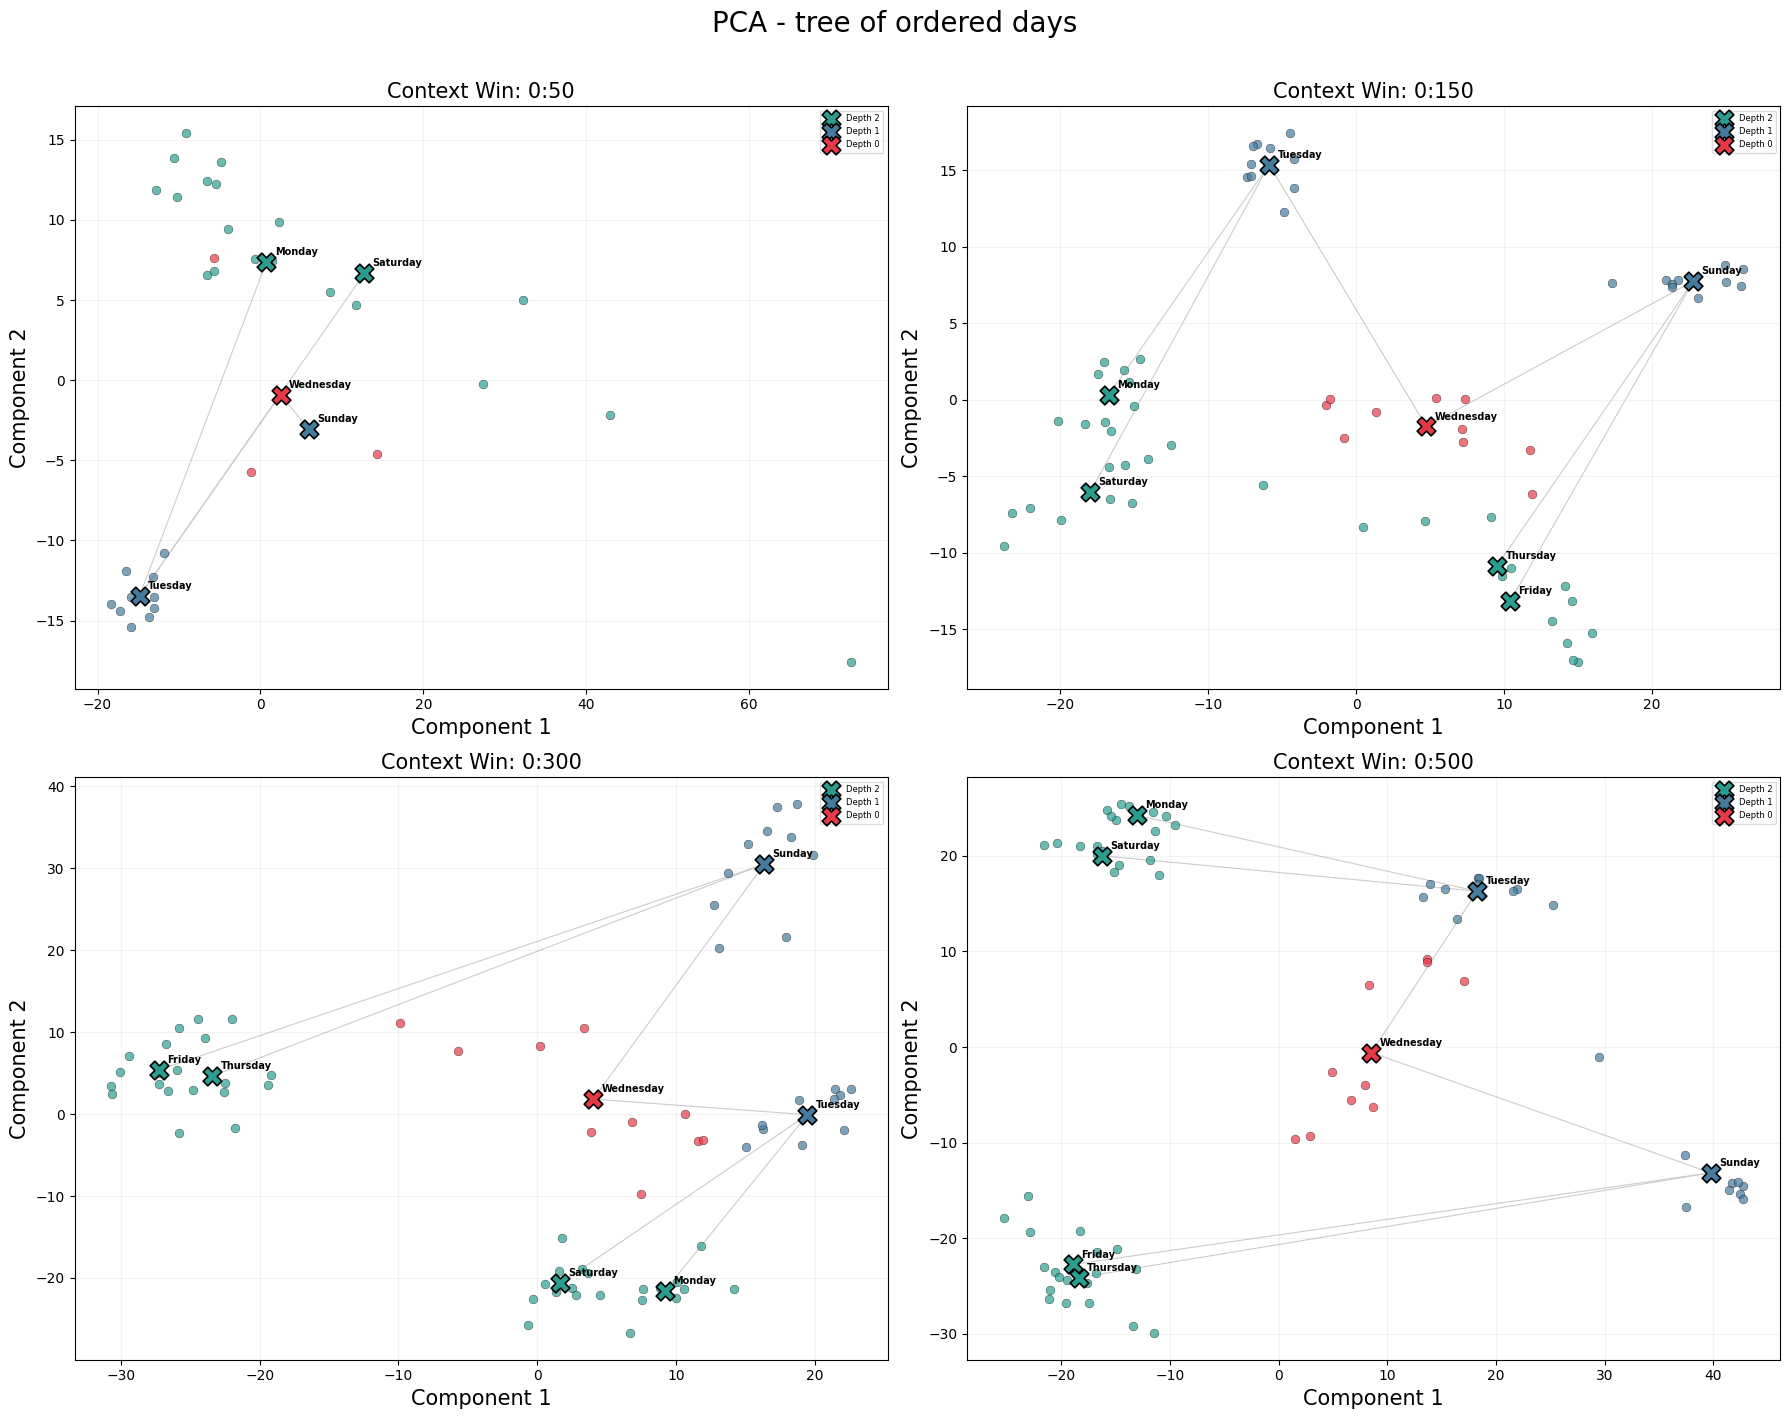

In [78]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_days/bin_tree_structure.txt")
EMB_DIR     = Path("../embeddings/reps&probs32/tree_days")

hp_tree_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,150,300,500]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=0)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_tree_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)
fig.suptitle("PCA - tree of ordered days",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_tree_ordered_days.png", dpi=300, bbox_inches='tight')
plt.show()

Processing context length: 2000, window=50
  after layer filter: n=673
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 6 occurrences in [0:50] (requested 10)
Processing context length: 2000, window=150
  after layer filter: n=673
Processing context length: 2000, window=300
  after layer filter: n=673
Processing context length: 2000, window=500
  after layer filter: n=673


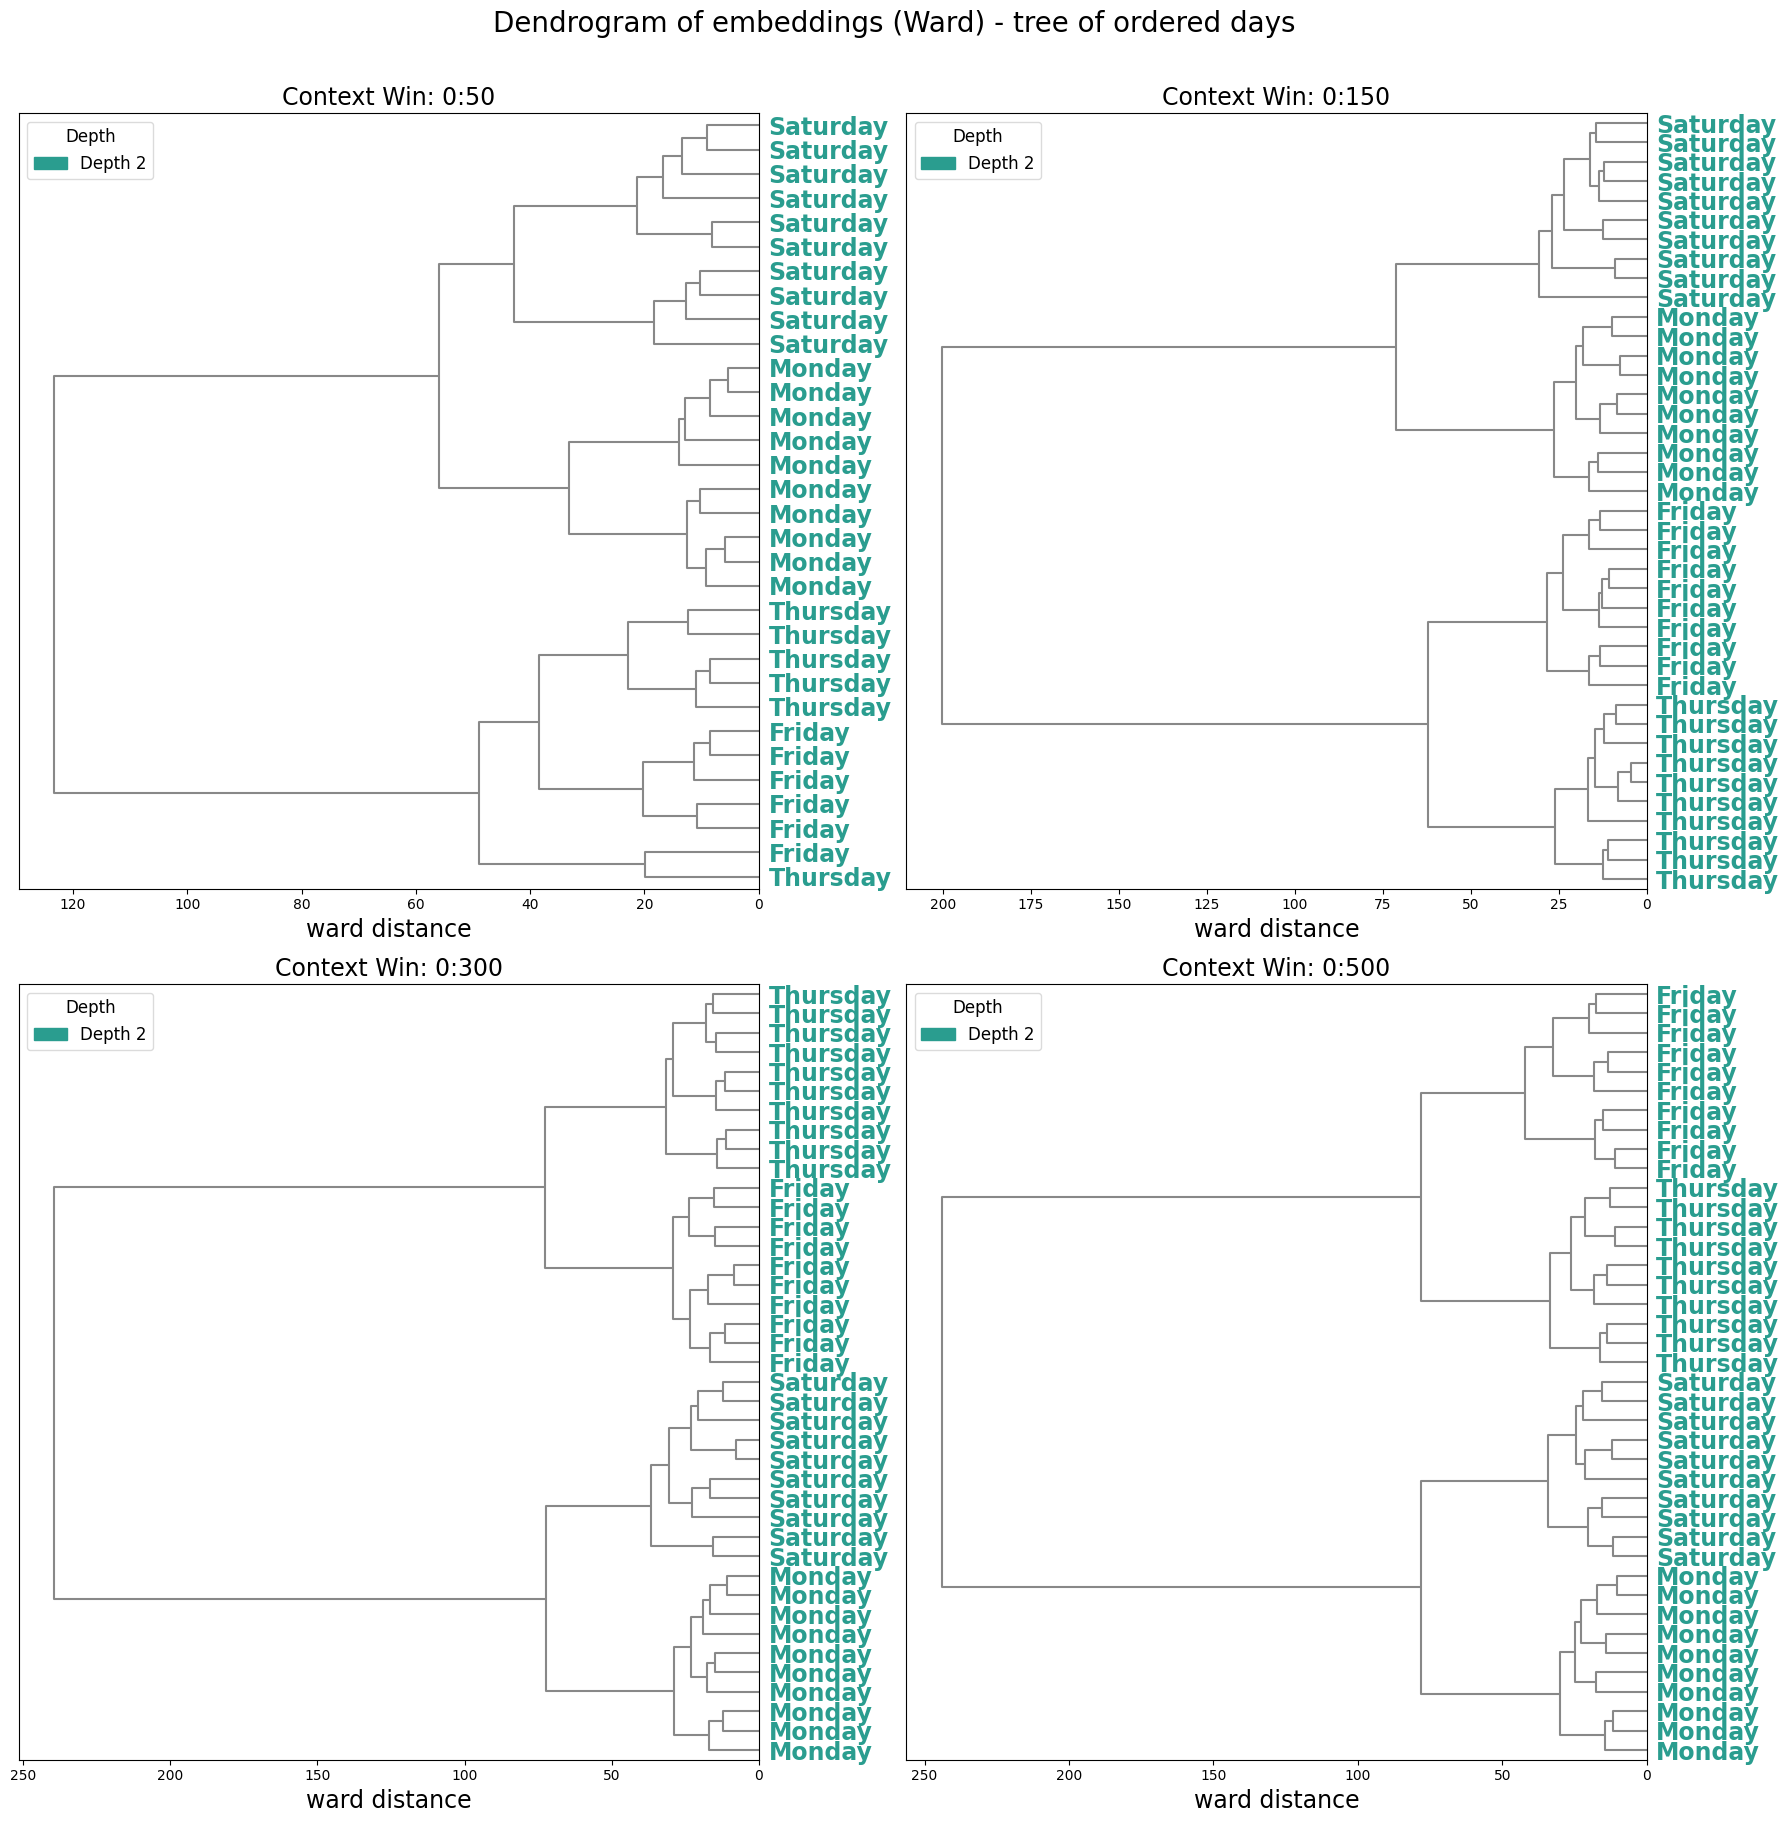

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 2

toks_layer_l = [toks for toks, depth in hp_tree_das.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree_das.word_to_tid[tok] for tok in toks_layer_l]

for ax, win_len in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {ctx}, window={win_len}")
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    # Keep only tokens from the selected layer
    mask_layer_l = np.isin(ids_np, ids_layer_l)
    ids_np_l = ids_np[mask_layer_l]
    emb_np_l = emb_np[mask_layer_l]

    print(f"  after layer filter: n={len(ids_np_l)}")

    filtered_ids, filtered_embs = _window_and_filter(
        ids_np_l,
        emb_np_l,
        hp_tree_das.id_to_word,
        k=10,
        t_end=win_len
    )

    hp_tree_das.plot_dendrogram_on_points(
        ax,
        filtered_ids,
        filtered_embs,
        title=f"Context Win: 0:{win_len}",
        method="ward",
        max_leaves=100
    )

fig.suptitle("Dendrogram of embeddings (Ward) - tree of ordered days",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/dendrogram_tree_ordered_days.png", dpi=300, bbox_inches='tight')
plt.show()

## Days Circle (ordered)

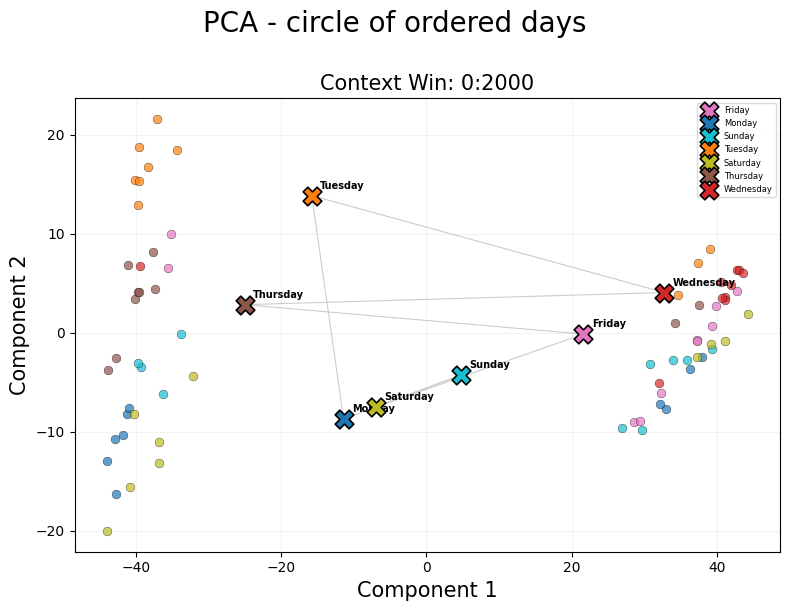

In [49]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/circle_days/circle_structure.txt")
EMB_DIR     = Path("../embeddings/reps&probs32/circle_days")

hp_circle_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


ctx = 2000
fig = plt.figure(figsize=(8, 6))
pt_path = EMB_DIR / f"reprs_circle_days_one_rw_2000_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)


filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                    k=10, t_start=0, t_end=2000)
reducer = PCA(n_components=2, random_state=42)
pca_result = reducer.fit_transform(filtered_embs)
hp_circle_das.plot_reduced_emb(fig.gca(), pca_result, filtered_ids, title=f"Context Win: 0:2000", only_centroid=False)
fig.suptitle("PCA - circle of ordered days",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_first_components_circle_ordered_days.png", dpi=300, bbox_inches='tight')
plt.show()

  [] Warning: token 'Saturday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 3 occurrences in [0:50] (requested 10)


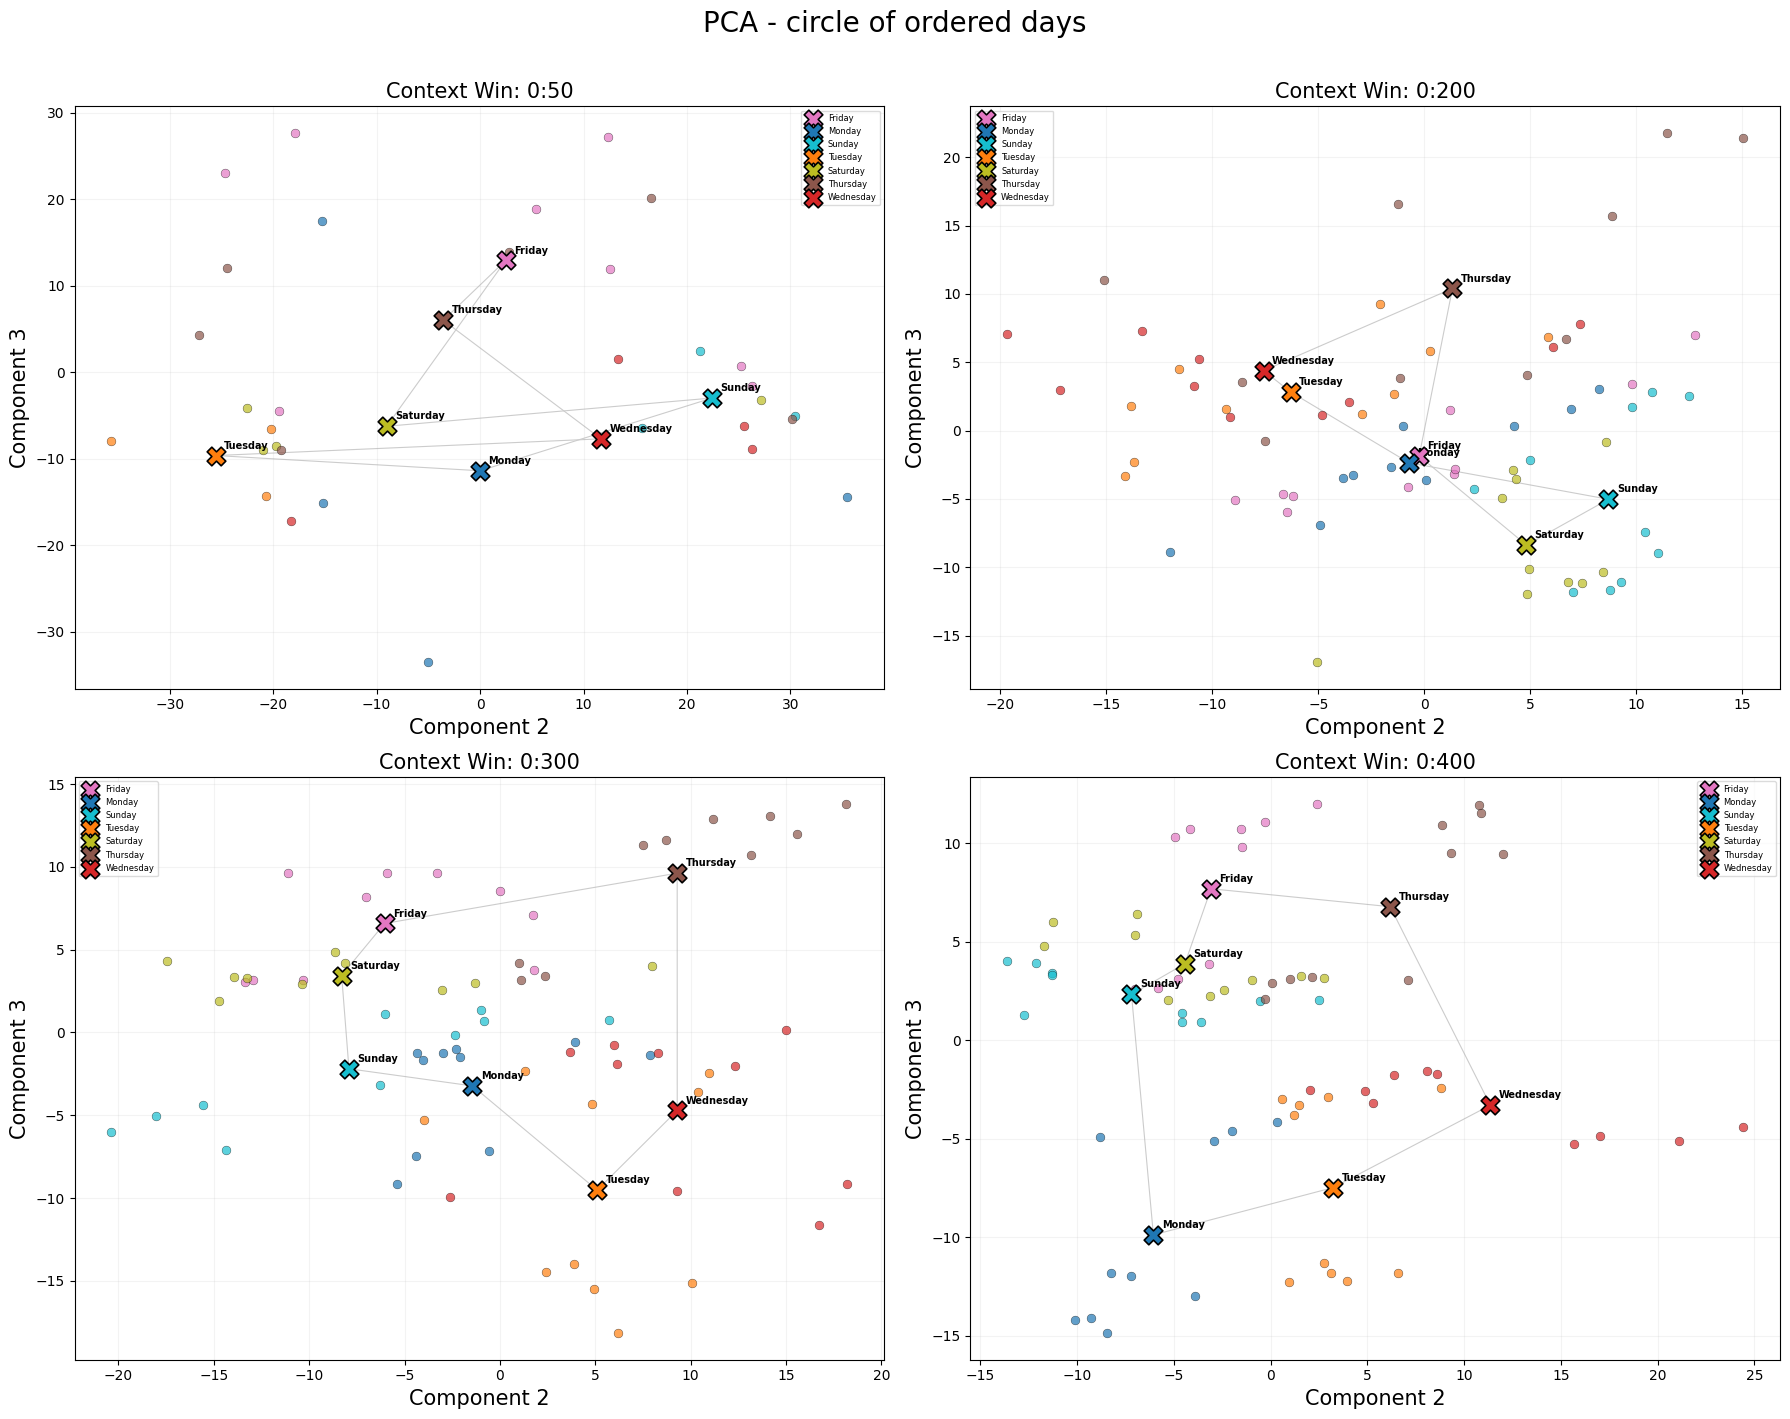

In [52]:

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,200,300,400]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=3, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=True)
fig.suptitle("PCA - circle of ordered days",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/pca_second_components_circle_ordered_days.png", dpi=300, bbox_inches='tight')
plt.show()

# BACKUP

## Exp 3.1: Numbers Tree - leaves only (ordered)

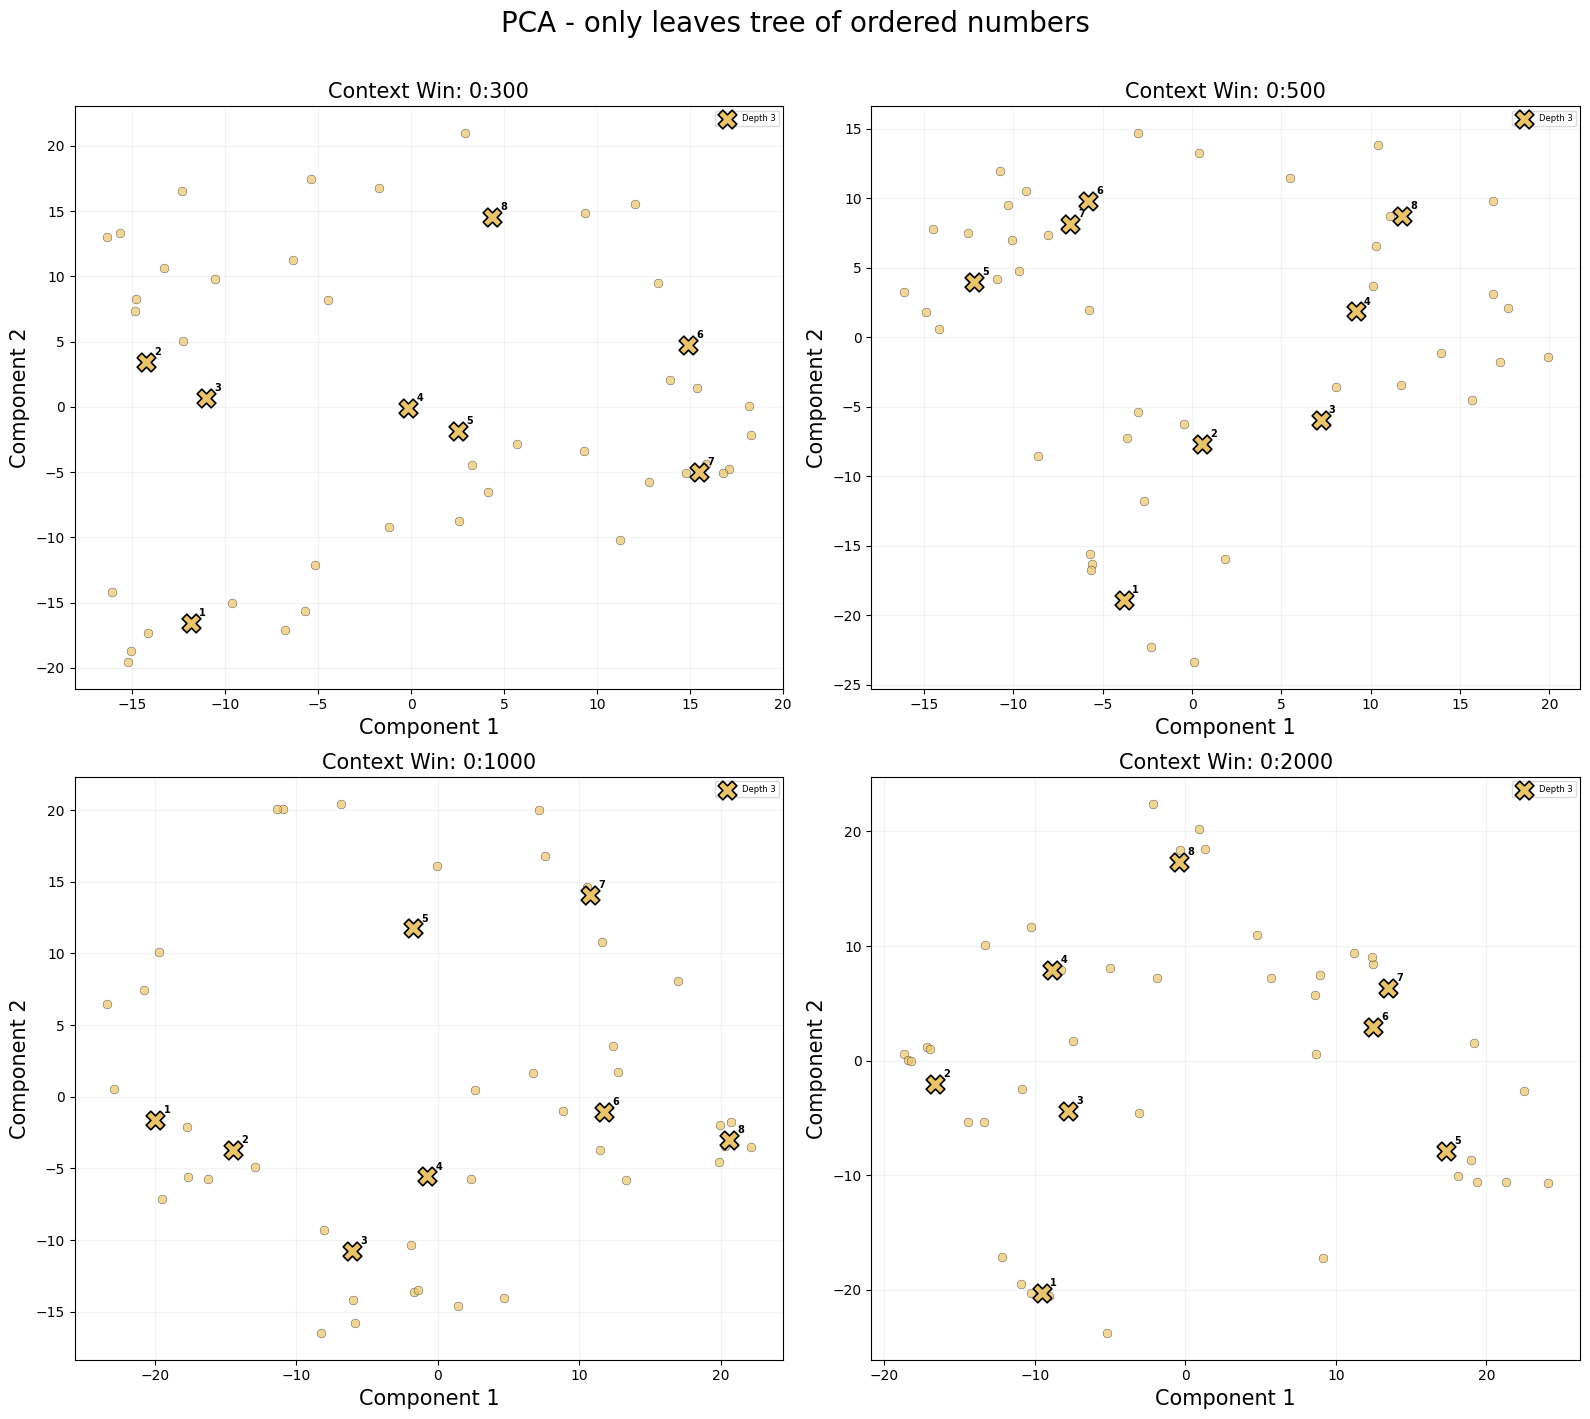

In [83]:
EMB_DIR     = Path("../embeddings/reps&probs32/only_leaves_ordered_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_ordered_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [  300, 500, 1000, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=5, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - only leaves tree of ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/pca_tree_only_leaves_ordered_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

Processing context length: 300
Processing context length: 500
Processing context length: 1000
Processing context length: 2000


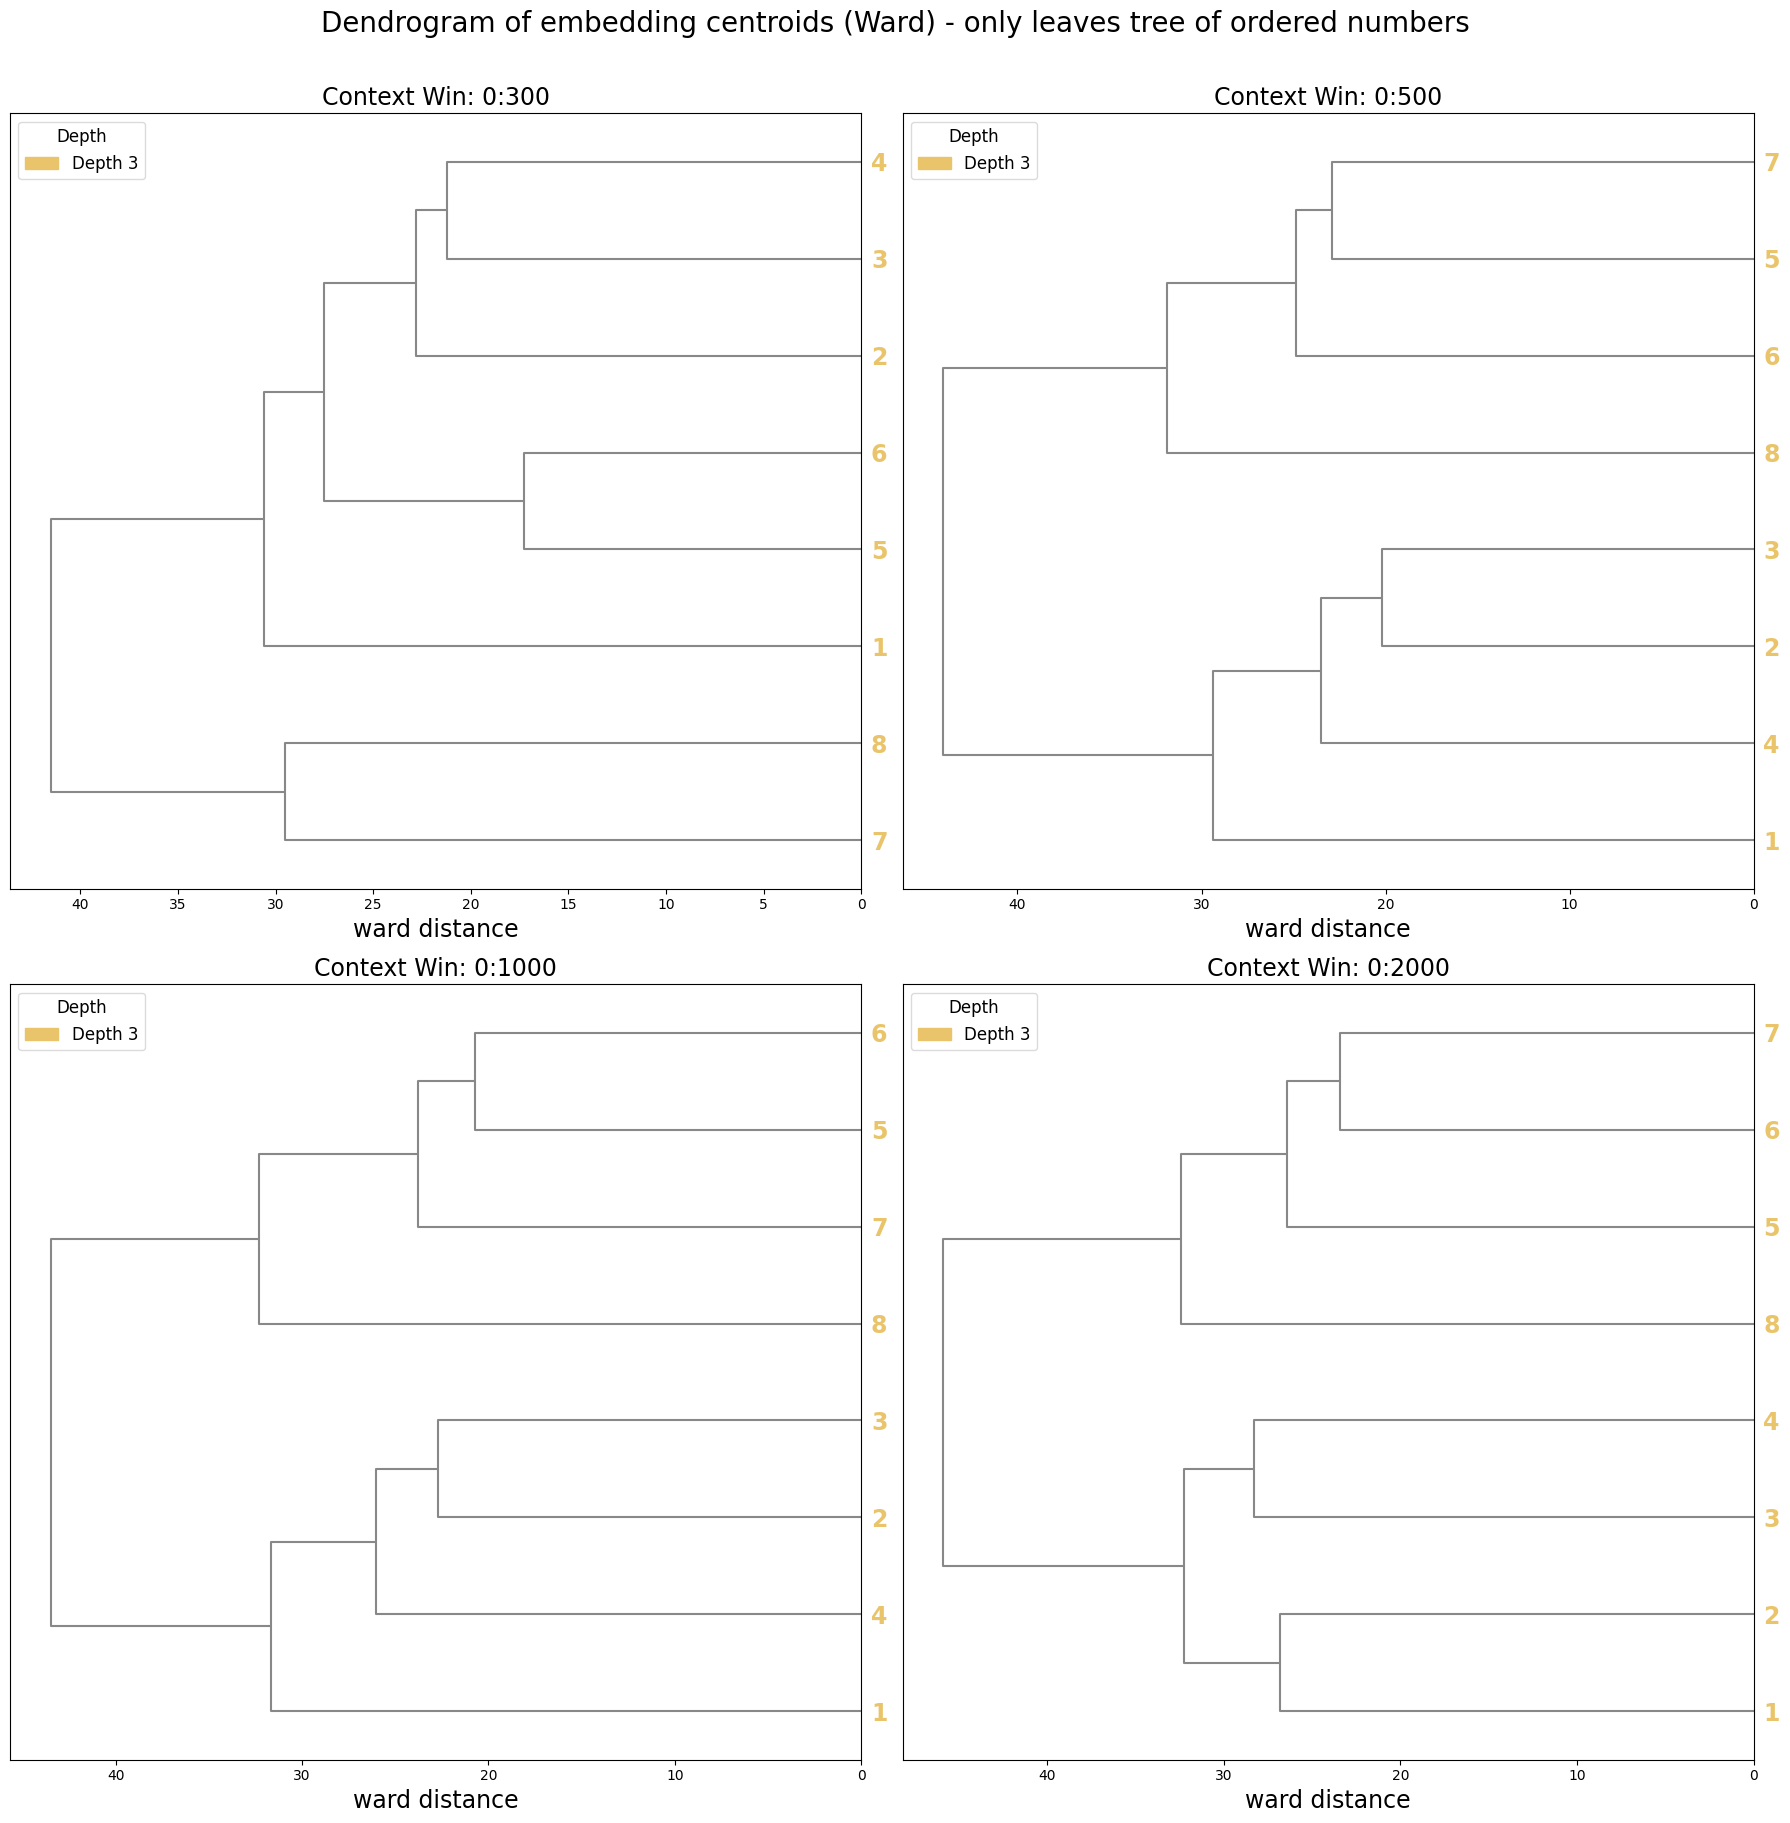

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Dendrogram of embedding centroids (Ward) - only leaves tree of ordered numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/dendrogram_tree_only_leaves_ordered_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

## Exp 3.2: Numbers Grid (shuffled) - VALUTARE CONTESTO PIÙ LUNGO

  [] Warning: token '15' has only 2 occurrences in [0:250] (requested 10)
  [] Warning: token '11' has only 4 occurrences in [0:250] (requested 10)
  [] Warning: token '13' has only 9 occurrences in [0:250] (requested 10)
  [] Warning: token '1' has only 7 occurrences in [0:250] (requested 10)
  [] Warning: token '2' has only 6 occurrences in [0:250] (requested 10)
  [] Warning: token '4' has only 2 occurrences in [0:250] (requested 10)
  [] Warning: token '5' has only 3 occurrences in [0:250] (requested 10)
  [] Warning: token '9' has only 7 occurrences in [0:250] (requested 10)
  [] Warning: token '10' has only 6 occurrences in [0:250] (requested 10)
  [] Warning: token '15' has only 8 occurrences in [0:500] (requested 10)
  [] Warning: token '11' has only 9 occurrences in [0:500] (requested 10)
  [] Warning: token '5' has only 5 occurrences in [0:500] (requested 10)


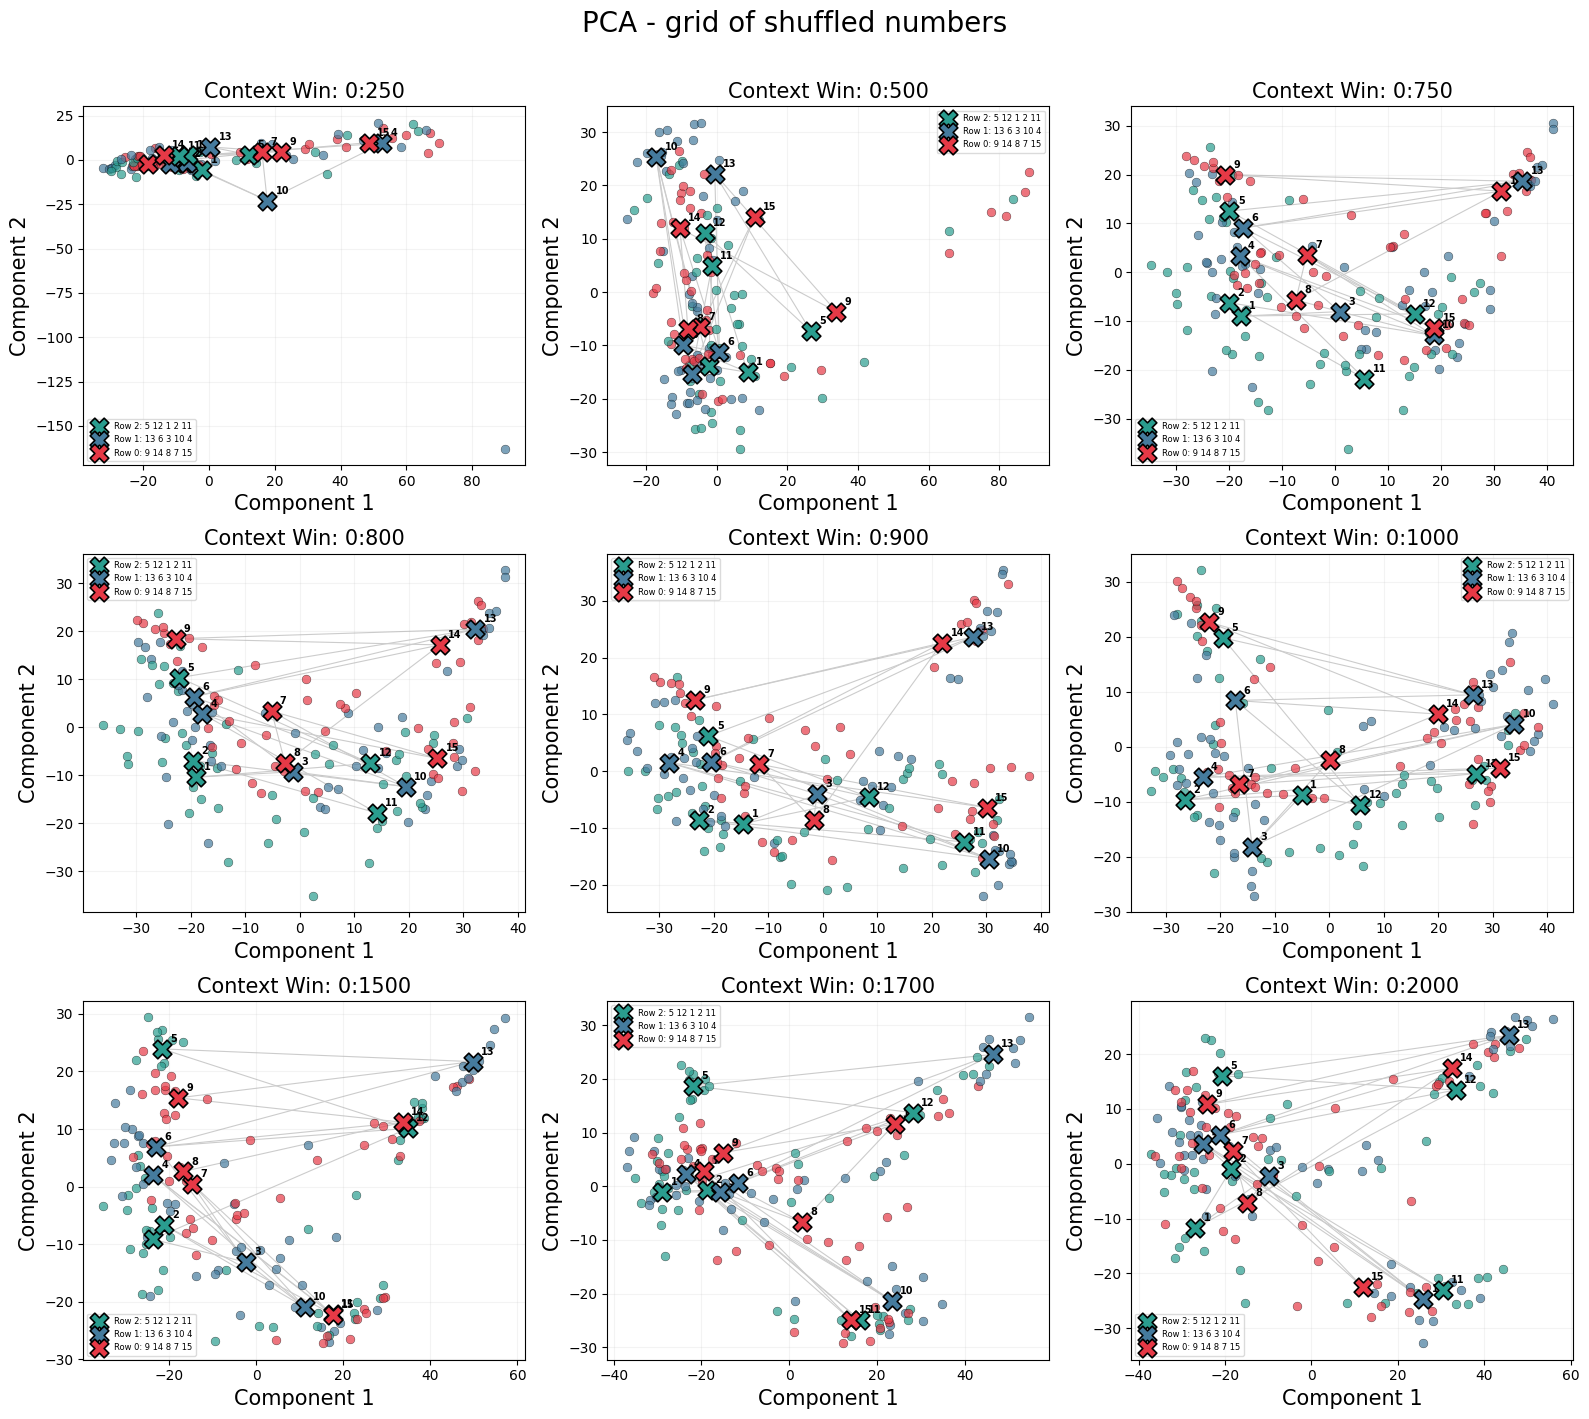

In [82]:
EMB_DIR     = Path("../embeddings/reps&probs32/shuffled_grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
ctx = 2000
CTX_LENS = [250,500, 750, 800, 900, 1000, 1500, 1700, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_numbers_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - grid of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/pca_grid_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

## Exp 5.2: Numbers Circle (shuffled) - BUTTARE

  [] Warning: token '15' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '14' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '2' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '4' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '6' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '10' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token '15' has only 9 occurrences in [0:500] (requested 10)


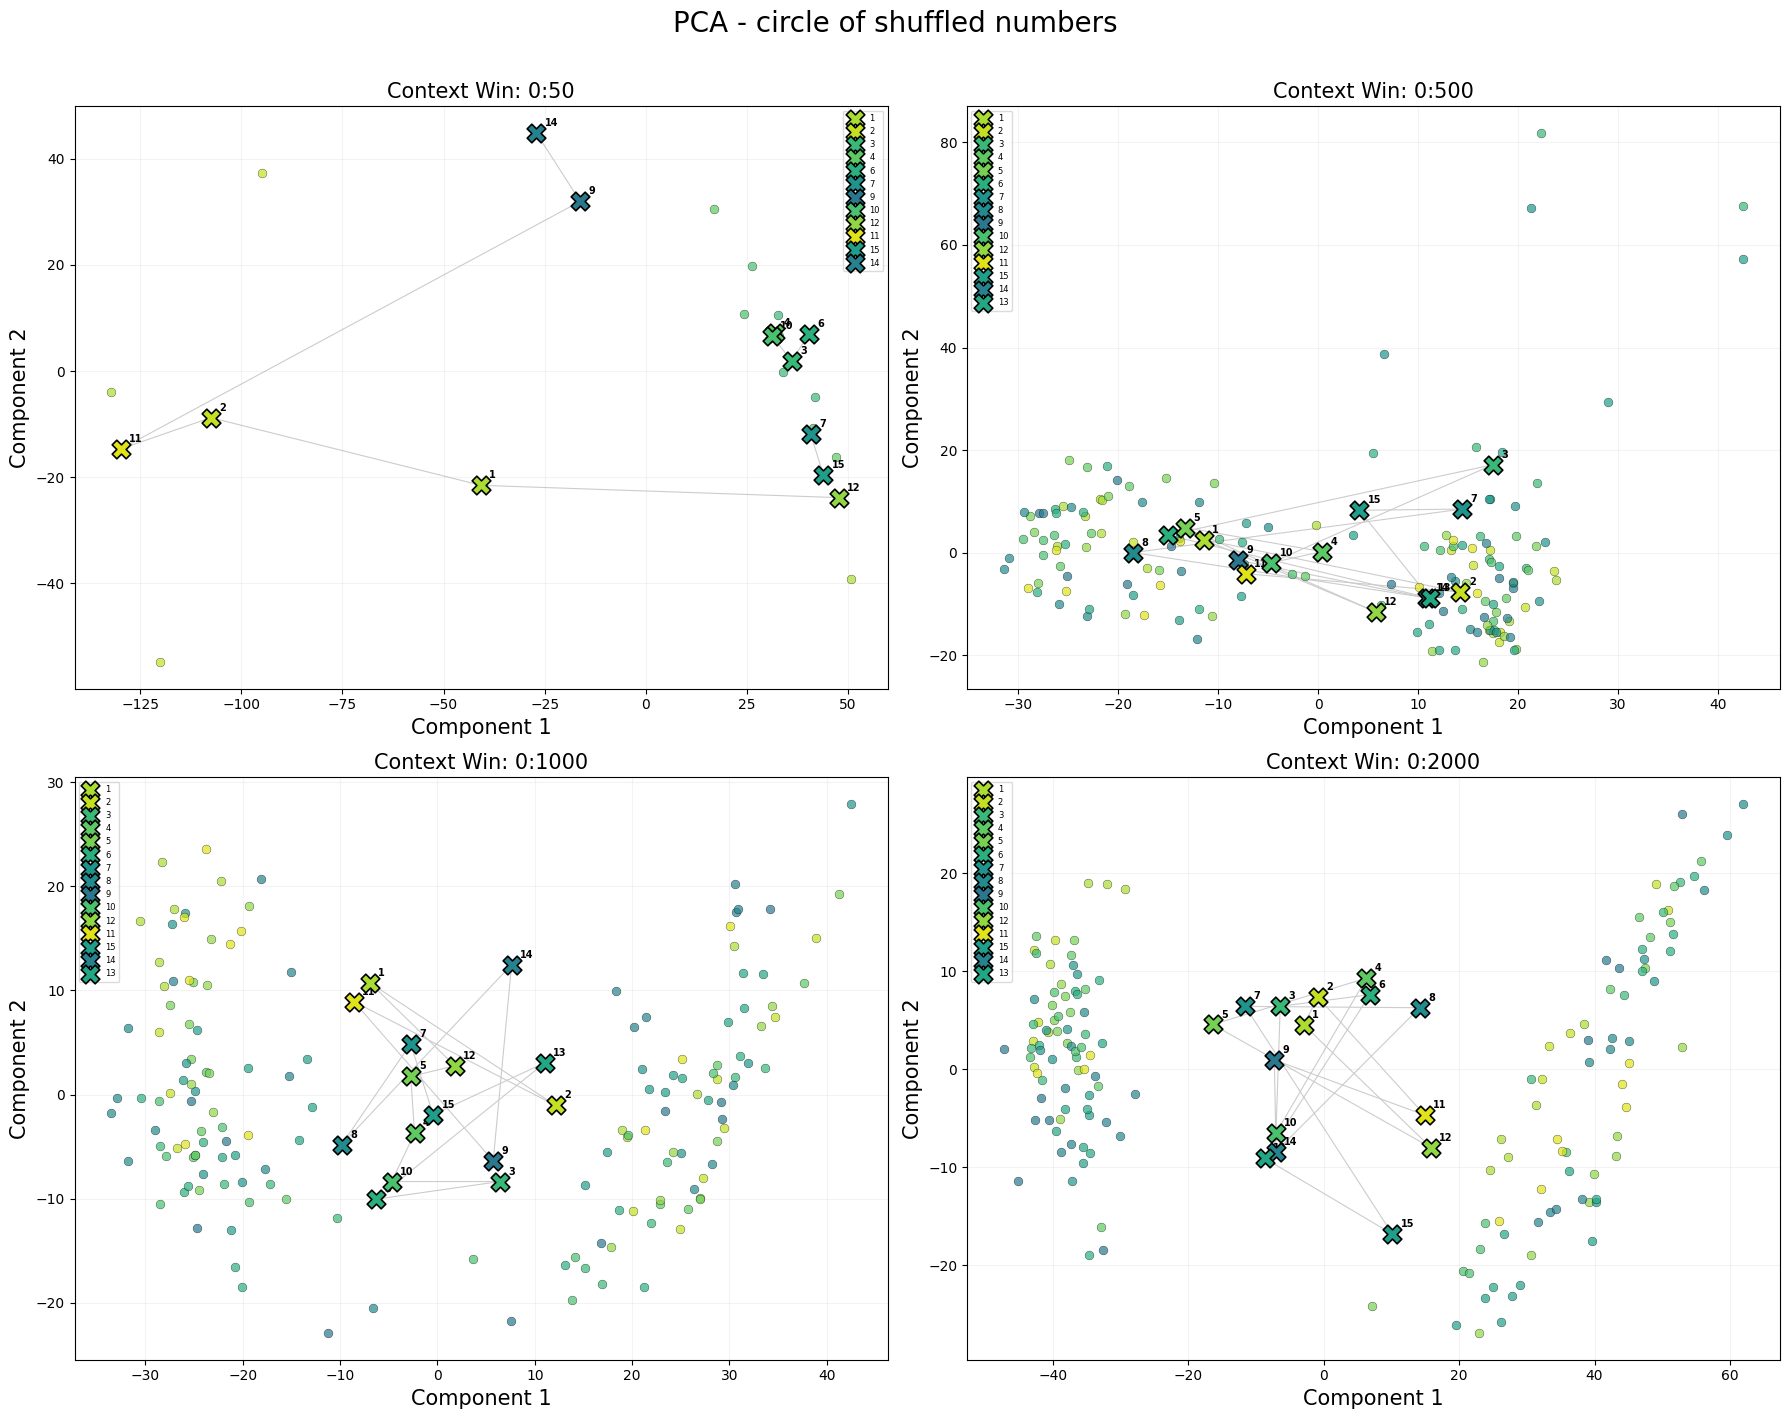

In [56]:
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_circle_numbers/circle_structure.txt")
EMB_DIR     = Path("../embeddings/reps&probs32/shuffled_circle_numbers")

hp_circle_num = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("PCA - circle of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/pca_first_components_circle_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

  [] Warning: token '15' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '14' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '1' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '2' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '3' has only 3 occurrences in [0:50] (requested 5)
  [] Warning: token '4' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '6' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '7' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '10' has only 4 occurrences in [0:50] (requested 5)
  [] Warning: token '13' has only 4 occurrences in [0:250] (requested 5)


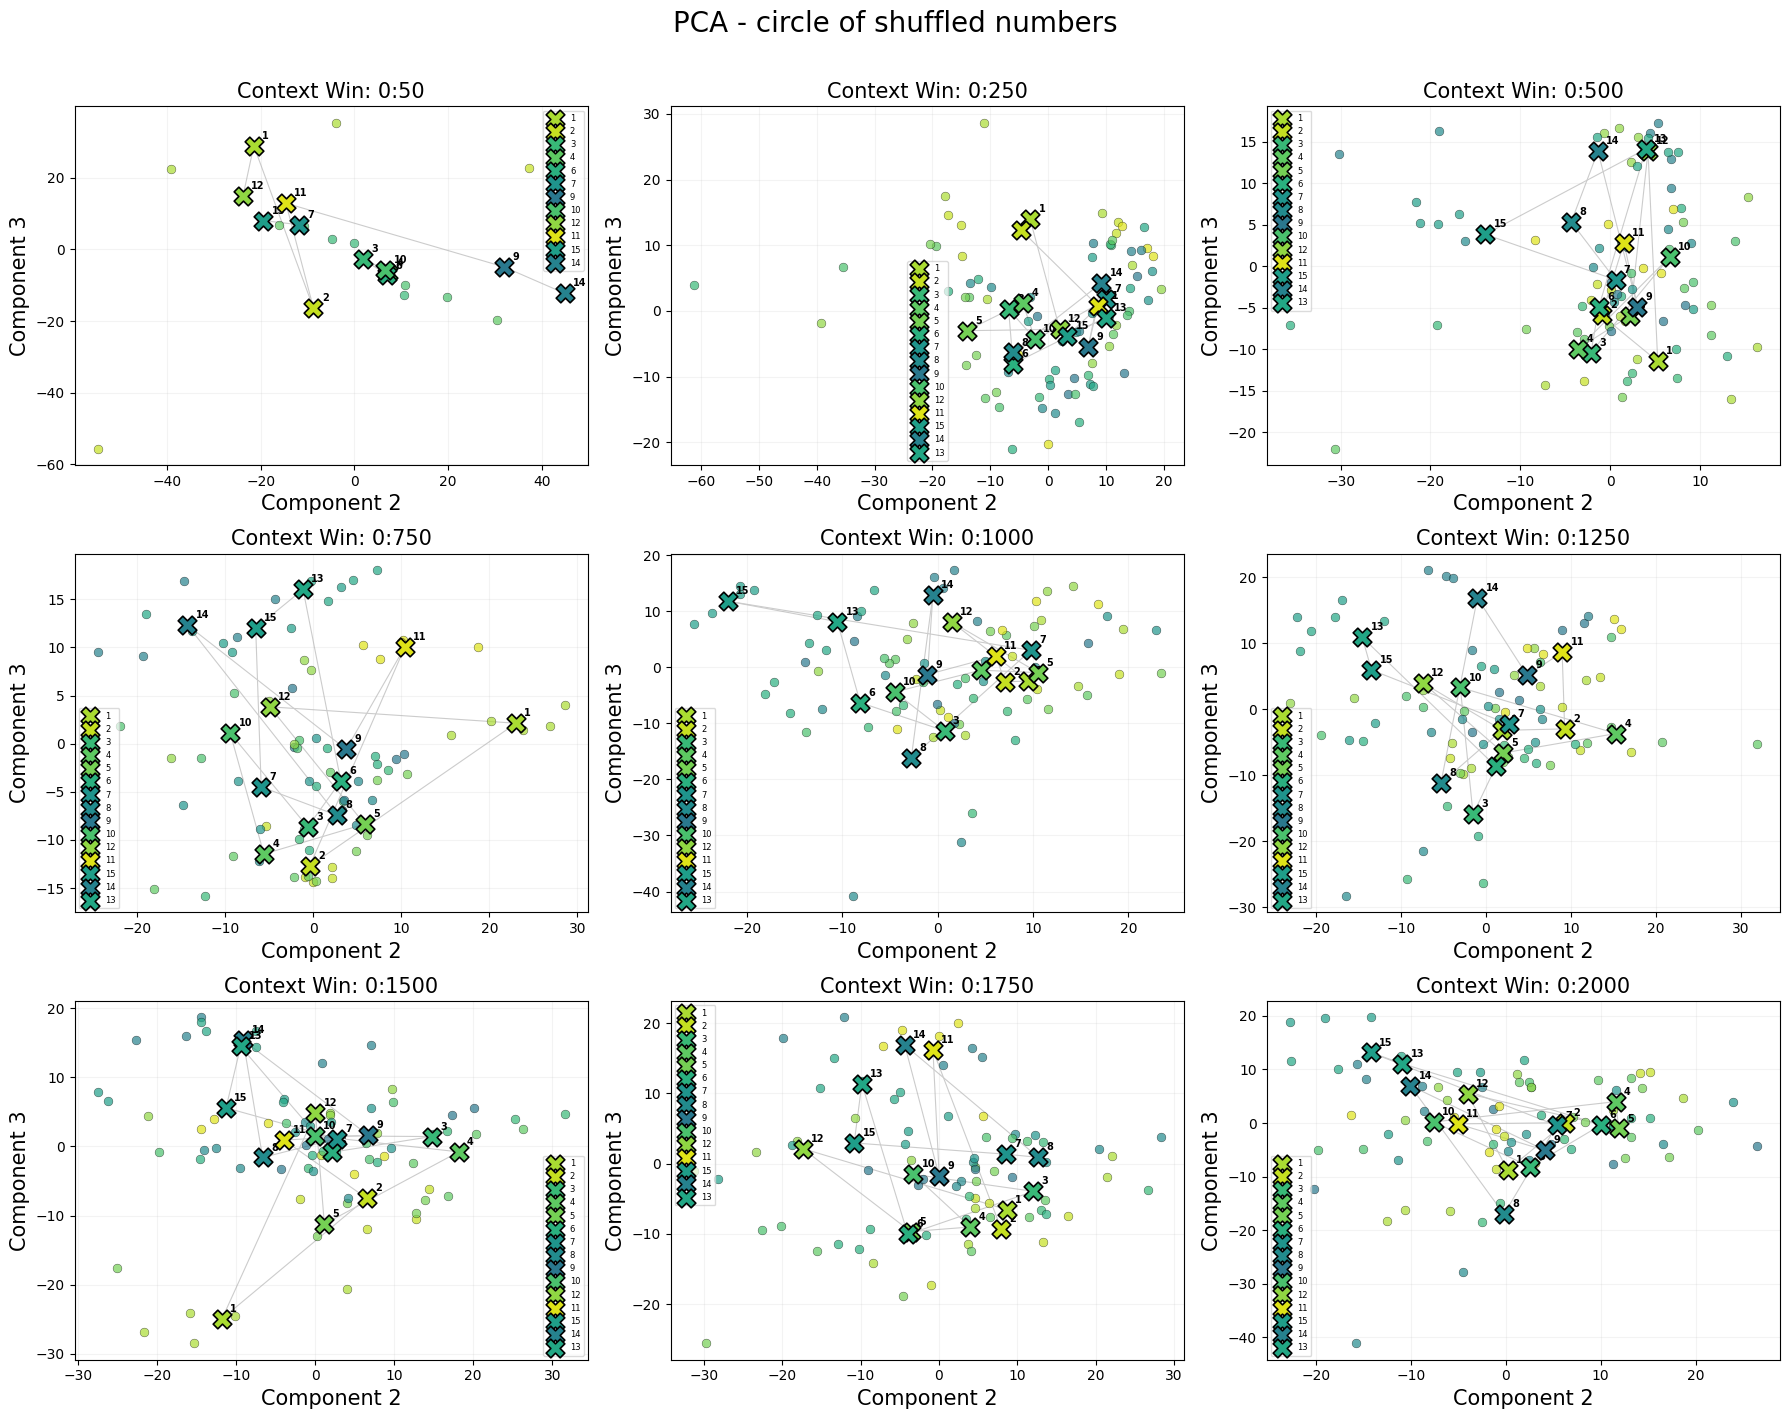

In [58]:

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,250,500, 750, 1000, 1250, 1500, 1750, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=5, t_start=0, t_end=win_len)
    reducer = PCA(n_components=3, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=True)
fig.suptitle("PCA - circle of shuffled numbers",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/pca_second_components_circle_shuffled_numbers.png", dpi=300, bbox_inches='tight')
plt.show()

## Days Circle (shuffled) - VALUTARE CONTESTO PIÙ LUNGO

vedere se si riproduce il risultato del paper in pc più alte

  [] Warning: token 'Saturday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 4 occurrences in [0:50] (requested 10)


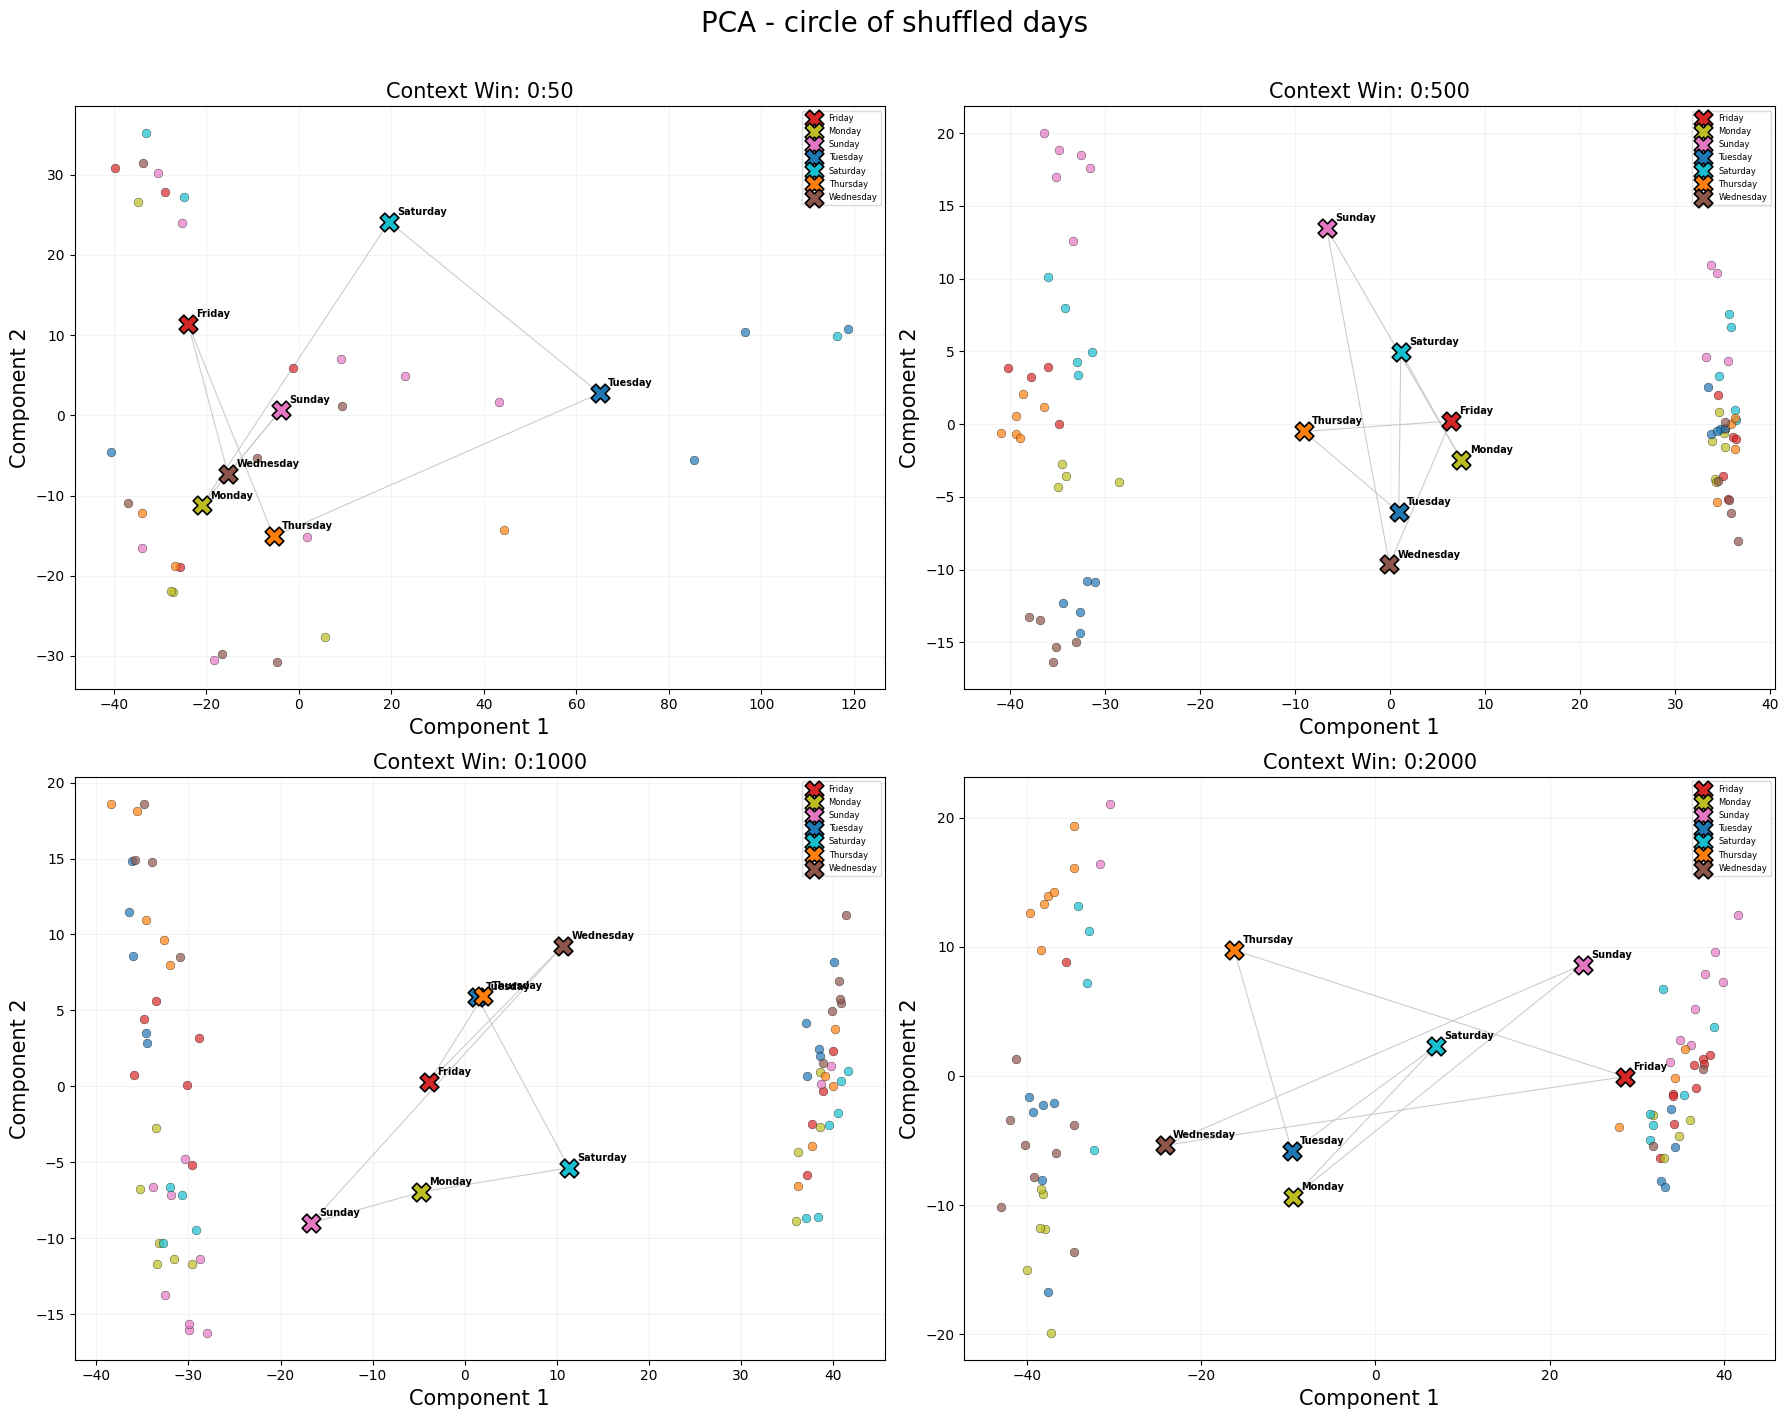

In [59]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_circle_days/circle_structure.txt")
EMB_DIR     = Path("../embeddings/reps&probs32/shuffled_circle_days")

hp_circle_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)
fig.suptitle("PCA - circle of shuffled days",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/pca_first_components_circle_shuffled_days.png", dpi=300, bbox_inches='tight')
plt.show()

  [] Warning: token 'Saturday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 4 occurrences in [0:50] (requested 10)


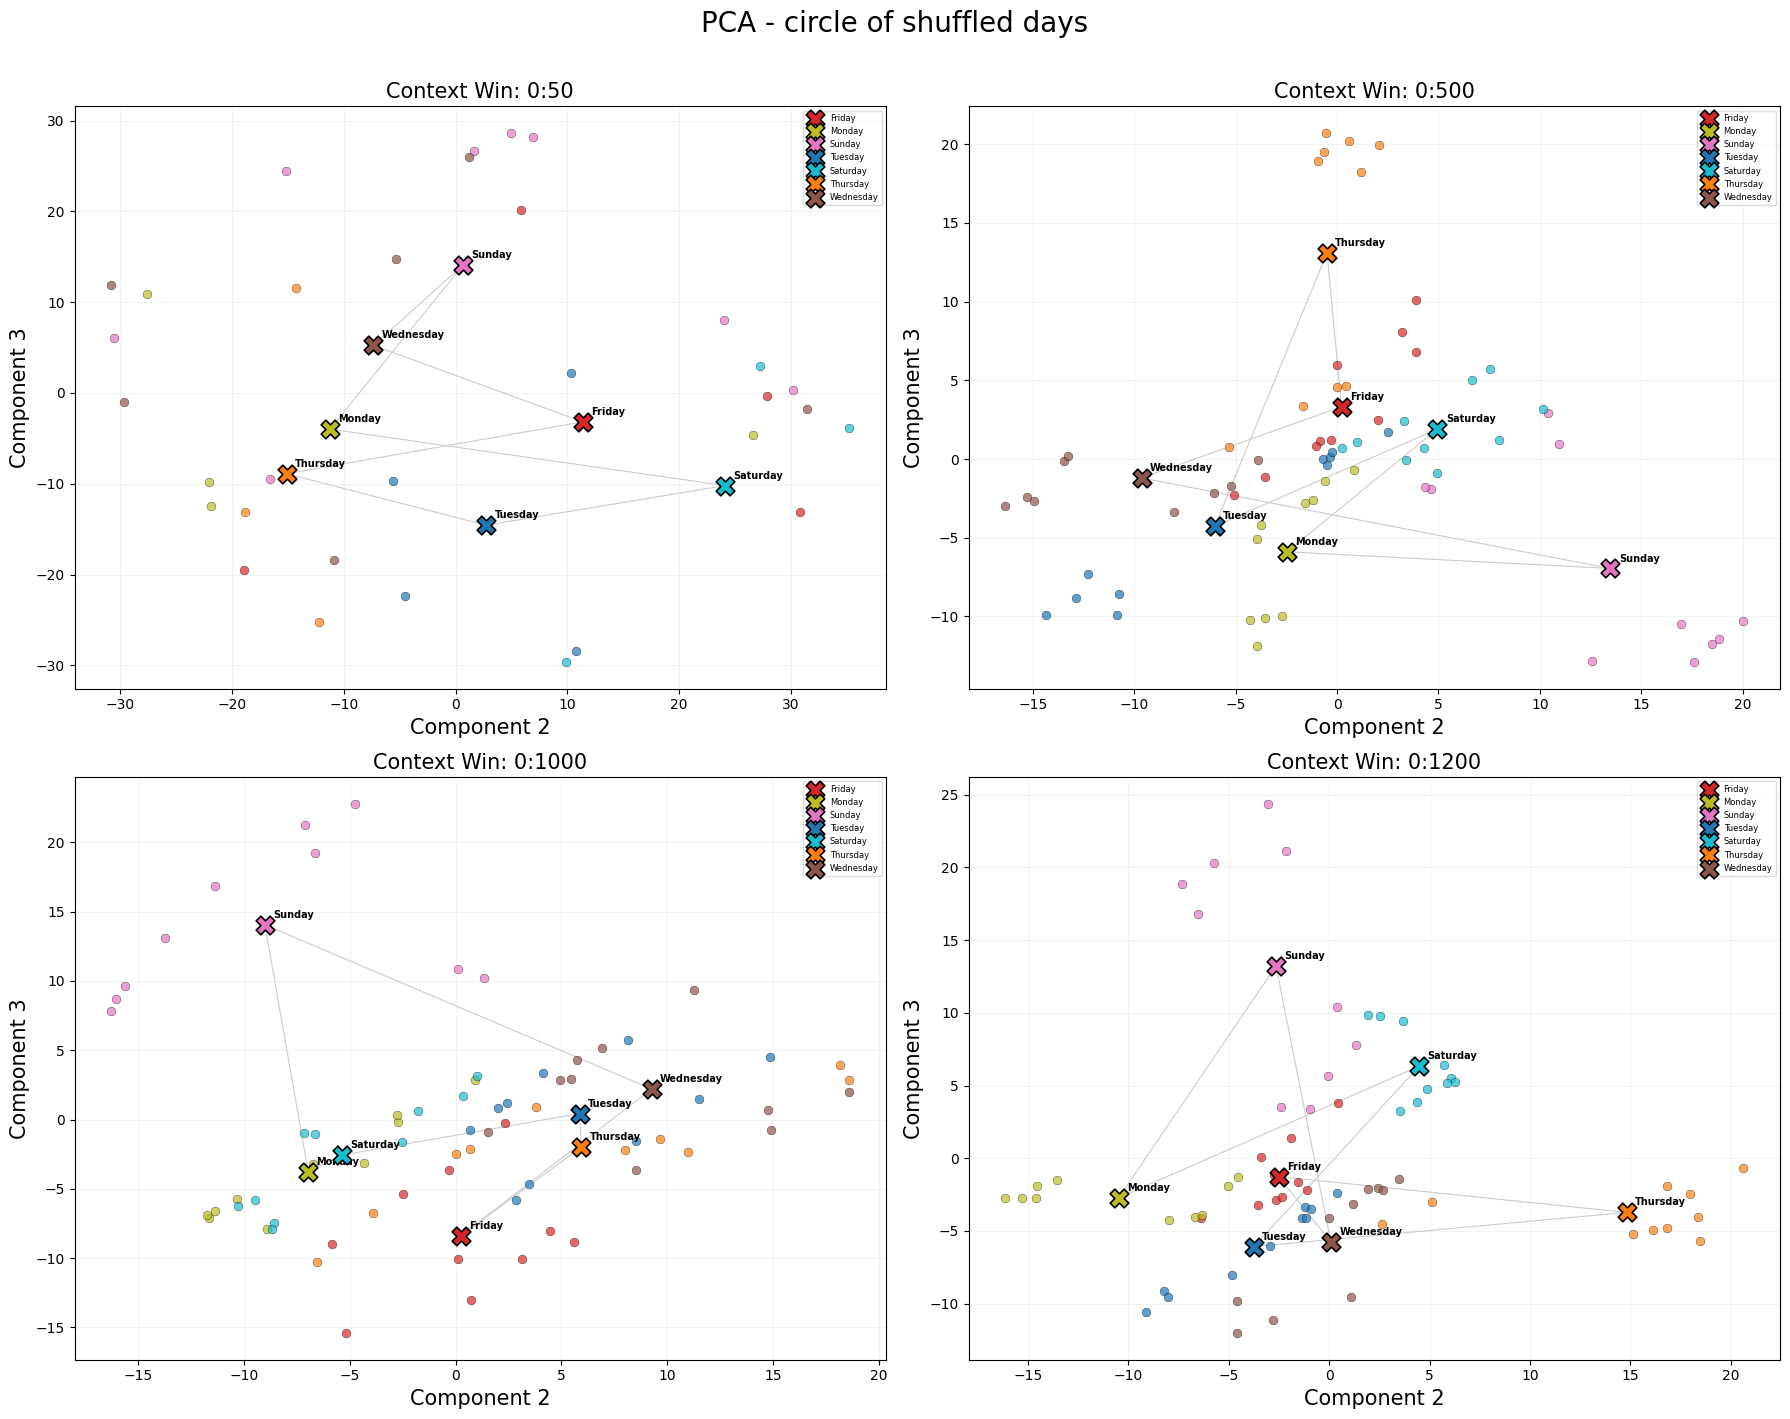

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000,1200]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_shuffled_one_rw_2000_line000000_layer32.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=4, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=True)
fig.suptitle("PCA - circle of shuffled days",
             fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig("../plots/backup_plots/pca_second_components_circle_shuffled_days.png", dpi=300, bbox_inches='tight')
plt.show()